In [39]:
import pandas as pd
import numpy as np

# Load the system.csv file
df = pd.read_csv('system.csv')

# Display basic info about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check the D-1 column specifically
print(f"\nD-1 column values:")
print(df['D-1'].values)

Dataset shape: (6, 324)

First few rows:
          StartDate           EndDate      Status        IPAddress  Progress  \
0  2025-09-23 12:09  2025-09-23 12:33  IP Address   41.122.132.157       100   
1  2025-09-23 12:08  2025-09-23 12:39  IP Address   201.71.175.179       100   
2  2025-09-23 12:10  2025-09-23 12:40  IP Address   105.245.16.132       100   
3  2025-09-23 12:09  2025-09-23 12:51  IP Address    84.40.152.181       100   
4  2025-09-23 12:09  2025-09-23 13:08  IP Address  105.216.129.235       100   

   Duration (in seconds)  Finished      RecordedDate         ResponseId  \
0                   1437      True  2025-09-23 12:33  R_8oYjOf6HKVsMWgK   
1                   1836      True  2025-09-23 12:39  R_5PvGEYb7qm8mHqD   
2                   1800      True  2025-09-23 12:40  R_2UwaTkc8g3CQeZP   
3                   2493      True  2025-09-23 12:51  R_81Y0JIPq2gz4dKC   
4                   3550      True  2025-09-23 13:08  R_87744uR2GLF9JI4   

   RecipientLastName  ...  

In [40]:
# Analyze D-1 (experience in years) for all 6 participants
print("Analysis of D-1 (Experience in years):")
print("="*40)

# Remove any NaN or empty values and convert to numeric
d1_values = pd.to_numeric(df['D-1'], errors='coerce').dropna()

print(f"Number of participants with D-1 data: {len(d1_values)}")
print(f"D-1 values: {list(d1_values)}")

# Calculate statistics
average_experience = d1_values.mean()
median_experience = d1_values.median()
min_experience = d1_values.min()
max_experience = d1_values.max()
std_experience = d1_values.std()

print(f"\nStatistical Summary:")
print(f"Average experience: {average_experience:.2f} years")
print(f"Median experience: {median_experience:.1f} years")
print(f"Minimum experience: {min_experience:.0f} years") 
print(f"Maximum experience: {max_experience:.0f} years")
print(f"Standard deviation: {std_experience:.2f} years")

Analysis of D-1 (Experience in years):
Number of participants with D-1 data: 6
D-1 values: [15, 6, 20, 5, 5, 6]

Statistical Summary:
Average experience: 9.50 years
Median experience: 6.0 years
Minimum experience: 5 years
Maximum experience: 20 years
Standard deviation: 6.41 years


## Fleiss' Kappa Inter-Rater Agreement Analysis

Analysis of inter-rater agreement for items A-1_1 through A-50_1 using Fleiss' Kappa coefficient. Each item should have 3 rater responses that will be evaluated for agreement.

In [41]:
# Install required package for Fleiss' Kappa if needed
try:
    import sklearn
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])

import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

def fleiss_kappa(ratings):
    """
    Calculate Fleiss' Kappa for multiple raters
    ratings: 2D array where rows are subjects and columns are raters
    """
    n_items, n_raters = ratings.shape
    
    # Get unique categories
    categories = np.unique(ratings[~np.isnan(ratings)])
    n_categories = len(categories)
    
    if n_categories < 2:
        return np.nan  # Can't calculate kappa with less than 2 categories
    
    # Create category mapping
    cat_to_idx = {cat: idx for idx, cat in enumerate(sorted(categories))}
    
    # Count matrix: items x categories
    count_matrix = np.zeros((n_items, n_categories))
    
    for i in range(n_items):
        for j in range(n_raters):
            if not np.isnan(ratings[i, j]):
                cat_idx = cat_to_idx[ratings[i, j]]
                count_matrix[i, cat_idx] += 1
    
    # Calculate observed agreement
    P_i = np.sum(count_matrix * (count_matrix - 1), axis=1) / (n_raters * (n_raters - 1))
    P_bar = np.mean(P_i)
    
    # Calculate expected agreement
    p_j = np.sum(count_matrix, axis=0) / (n_items * n_raters)
    P_e = np.sum(p_j ** 2)
    
    # Calculate Fleiss' Kappa
    if P_e == 1.0:
        return np.nan  # Perfect expected agreement, undefined kappa
    
    kappa = (P_bar - P_e) / (1 - P_e)
    return kappa

def interpret_kappa(kappa):
    """
    Interpret Fleiss' Kappa values based on Landis & Koch (1977) guidelines
    """
    if np.isnan(kappa):
        return "Undefined"
    elif kappa < 0:
        return "Poor (Less than chance agreement)"
    elif kappa < 0.20:
        return "Slight"
    elif kappa < 0.40:
        return "Fair"
    elif kappa < 0.60:
        return "Moderate"
    elif kappa < 0.80:
        return "Substantial"
    else:
        return "Almost Perfect"

print("Fleiss' Kappa Analysis for A-1_1 through A-50_1")
print("=" * 60)

Fleiss' Kappa Analysis for A-1_1 through A-50_1


In [42]:
# Load the data and identify A-1_1 through A-50_1 columns
df = pd.read_csv('system.csv')

# Find all columns that match the pattern A-XX_1 where XX is 1-50
a_columns = []
for i in range(1, 51):
    col_name = f'A-{i}_1'
    if col_name in df.columns:
        a_columns.append(col_name)

print(f"Found {len(a_columns)} columns matching A-1_1 through A-50_1 pattern")
print(f"Columns: {a_columns[:5]}...{a_columns[-5:] if len(a_columns) > 10 else a_columns[5:]}")

if len(a_columns) == 0:
    print("No columns found matching the pattern. Checking available columns...")
    print("Available columns:", list(df.columns))
else:
    print(f"\nDataset has {df.shape[0]} rows (should represent multiple raters for each item)")
    print(f"Sample data from first few A columns:")
    print(df[a_columns[:3]].head())

# Check if we have exactly 3 raters per item (expecting 3 rows total)
print(f"\nData shape: {df.shape}")
if df.shape[0] == 3:
    print("✓ Detected 3 raters (rows) - perfect for Fleiss' Kappa analysis")
elif df.shape[0] > 3:
    print(f"⚠ Warning: {df.shape[0]} rows detected. Expected 3 for inter-rater analysis.")
    print("Will use first 3 rows as raters.")
else:
    print(f"⚠ Warning: Only {df.shape[0]} rows detected. Need at least 2 raters for agreement analysis.")

Found 50 columns matching A-1_1 through A-50_1 pattern
Columns: ['A-1_1', 'A-2_1', 'A-3_1', 'A-4_1', 'A-5_1']...['A-46_1', 'A-47_1', 'A-48_1', 'A-49_1', 'A-50_1']

Dataset has 6 rows (should represent multiple raters for each item)
Sample data from first few A columns:
   A-1_1  A-2_1  A-3_1
0    7.0    5.0    5.0
1    6.0    7.0    5.0
2    7.0    6.0    6.0
3    NaN    NaN    NaN
4    NaN    NaN    NaN

Data shape: (6, 324)
⚠ Warning: 6 rows detected. Expected 3 for inter-rater analysis.
Will use first 3 rows as raters.


In [43]:
# Calculate Fleiss' Kappa for each A-XX_1 item
results = []
kappa_values = []

print("Calculating Fleiss' Kappa for each item...")
print("=" * 50)

for col in a_columns:
    # Get ratings for this item (transpose so items are rows, raters are columns)
    # Each row in the original data represents a rater, so we take the values for this column
    ratings_for_item = df[col].values[:3]  # Use first 3 rows as the 3 raters
    
    # Convert to numeric, handling any text values
    numeric_ratings = []
    for rating in ratings_for_item:
        try:
            if pd.isna(rating):
                numeric_ratings.append(np.nan)
            else:
                # Try to convert to number
                numeric_ratings.append(float(rating))
        except (ValueError, TypeError):
            # If it's text, we'll need to convert to numeric scale
            # For now, treat as missing data
            numeric_ratings.append(np.nan)
    
    # Reshape for Fleiss' Kappa calculation (1 item, 3 raters)
    ratings_matrix = np.array(numeric_ratings).reshape(1, -1)
    
    # Calculate Fleiss' Kappa
    kappa = fleiss_kappa(ratings_matrix)
    interpretation = interpret_kappa(kappa)
    
    # Store results
    results.append({
        'Item': col,
        'Kappa': kappa,
        'Interpretation': interpretation,
        'Rater_1': numeric_ratings[0] if len(numeric_ratings) > 0 else np.nan,
        'Rater_2': numeric_ratings[1] if len(numeric_ratings) > 1 else np.nan,
        'Rater_3': numeric_ratings[2] if len(numeric_ratings) > 2 else np.nan
    })
    
    if not np.isnan(kappa):
        kappa_values.append(kappa)
    
    # Print detailed results for first 10 items and last 5 items
    if len(results) <= 10 or len(results) > len(a_columns) - 5:
        print(f"{col}: κ = {kappa:.3f} ({interpretation})")
        print(f"   Ratings: {numeric_ratings}")
        print()

# Create results DataFrame
results_df = pd.DataFrame(results)

print(f"\nCompleted analysis for {len(a_columns)} items")
print(f"Valid Kappa calculations: {len(kappa_values)}")
print(f"Items with undefined Kappa: {len(a_columns) - len(kappa_values)}")

# Display first few results
print(f"\nFirst 10 results:")
print(results_df.head(10)[['Item', 'Kappa', 'Interpretation']])

Calculating Fleiss' Kappa for each item...
A-1_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [7.0, 6.0, 7.0]

A-2_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [5.0, 7.0, 6.0]

A-3_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [5.0, 5.0, 6.0]

A-4_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [7.0, 2.0, 6.0]

A-5_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [5.0, 6.0, 6.0]

A-6_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [4.0, 2.0, 6.0]

A-7_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [5.0, 5.0, 6.0]

A-8_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [5.0, 3.0, 6.0]

A-9_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [4.0, 3.0, 6.0]

A-10_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [4.0, 3.0, 3.0]

A-46_1: κ = -0.500 (Poor (Less than chance agreement))
   Ratings: [6.0, 4.0, 7.0]

A-47_1: κ = -0.500 (Poor (Less than chance

In [44]:
# Comprehensive summary and analysis
print("FLEISS' KAPPA INTER-RATER AGREEMENT SUMMARY")
print("=" * 60)

# Overall statistics
if len(kappa_values) > 0:
    mean_kappa = np.mean(kappa_values)
    median_kappa = np.median(kappa_values)
    std_kappa = np.std(kappa_values)
    min_kappa = np.min(kappa_values)
    max_kappa = np.max(kappa_values)
    
    print(f"\nOverall Kappa Statistics (n={len(kappa_values)}):")
    print(f"  Mean κ: {mean_kappa:.3f}")
    print(f"  Median κ: {median_kappa:.3f}")
    print(f"  Std Dev: {std_kappa:.3f}")
    print(f"  Range: {min_kappa:.3f} to {max_kappa:.3f}")

# Agreement level distribution
agreement_counts = results_df['Interpretation'].value_counts()
print(f"\nAgreement Level Distribution:")
print("-" * 40)
for level, count in agreement_counts.items():
    percentage = (count / len(results_df)) * 100
    print(f"  {level:<25}: {count:3d} items ({percentage:5.1f}%)")

# High vs Low Agreement Classification
high_agreement_threshold = 0.60  # Substantial or better
low_agreement_threshold = 0.40   # Below moderate

high_agreement_items = results_df[results_df['Kappa'] >= high_agreement_threshold]
moderate_agreement_items = results_df[(results_df['Kappa'] >= low_agreement_threshold) & 
                                    (results_df['Kappa'] < high_agreement_threshold)]
low_agreement_items = results_df[results_df['Kappa'] < low_agreement_threshold]
undefined_items = results_df[results_df['Kappa'].isna()]

print(f"\nAgreement Classification Summary:")
print("-" * 40)
print(f"HIGH Agreement (κ ≥ 0.60):     {len(high_agreement_items):3d} items ({len(high_agreement_items)/len(results_df)*100:5.1f}%)")
print(f"MODERATE Agreement (0.40-0.59): {len(moderate_agreement_items):3d} items ({len(moderate_agreement_items)/len(results_df)*100:5.1f}%)")
print(f"LOW Agreement (κ < 0.40):       {len(low_agreement_items):3d} items ({len(low_agreement_items)/len(results_df)*100:5.1f}%)")
print(f"UNDEFINED (insufficient data):   {len(undefined_items):3d} items ({len(undefined_items)/len(results_df)*100:5.1f}%)")

# Detailed breakdown for high and low agreement items
if len(high_agreement_items) > 0:
    print(f"\nHIGH AGREEMENT ITEMS (κ ≥ 0.60):")
    print("-" * 30)
    for _, row in high_agreement_items.iterrows():
        print(f"  {row['Item']}: κ = {row['Kappa']:.3f} ({row['Interpretation']})")

if len(low_agreement_items) > 0:
    print(f"\nLOW AGREEMENT ITEMS (κ < 0.40):")
    print("-" * 30)
    for _, row in low_agreement_items.head(10).iterrows():  # Show first 10
        print(f"  {row['Item']}: κ = {row['Kappa']:.3f} ({row['Interpretation']})")
    if len(low_agreement_items) > 10:
        print(f"  ... and {len(low_agreement_items) - 10} more items")

# Items with perfect agreement or disagreement
perfect_agreement = results_df[results_df['Kappa'] == 1.0]
no_agreement = results_df[results_df['Kappa'] <= 0.0]

if len(perfect_agreement) > 0:
    print(f"\nPERFECT AGREEMENT ITEMS (κ = 1.0): {len(perfect_agreement)} items")
    for _, row in perfect_agreement.iterrows():
        print(f"  {row['Item']}: All raters agreed")

if len(no_agreement) > 0:
    print(f"\nNO/NEGATIVE AGREEMENT ITEMS (κ ≤ 0.0): {len(no_agreement)} items")
    for _, row in no_agreement.iterrows():
        print(f"  {row['Item']}: κ = {row['Kappa']:.3f} (Worse than chance)")

FLEISS' KAPPA INTER-RATER AGREEMENT SUMMARY

Overall Kappa Statistics (n=50):
  Mean κ: -0.500
  Median κ: -0.500
  Std Dev: 0.000
  Range: -0.500 to -0.500

Agreement Level Distribution:
----------------------------------------
  Poor (Less than chance agreement):  50 items (100.0%)

Agreement Classification Summary:
----------------------------------------
HIGH Agreement (κ ≥ 0.60):       0 items (  0.0%)
MODERATE Agreement (0.40-0.59):   0 items (  0.0%)
LOW Agreement (κ < 0.40):        50 items (100.0%)
UNDEFINED (insufficient data):     0 items (  0.0%)

LOW AGREEMENT ITEMS (κ < 0.40):
------------------------------
  A-1_1: κ = -0.500 (Poor (Less than chance agreement))
  A-2_1: κ = -0.500 (Poor (Less than chance agreement))
  A-3_1: κ = -0.500 (Poor (Less than chance agreement))
  A-4_1: κ = -0.500 (Poor (Less than chance agreement))
  A-5_1: κ = -0.500 (Poor (Less than chance agreement))
  A-6_1: κ = -0.500 (Poor (Less than chance agreement))
  A-7_1: κ = -0.500 (Poor (Less tha

## Key Findings and Interpretation

**Critical Finding:** All 50 survey items (A-1_1 through A-50_1) show identical Fleiss' Kappa values of **κ = -0.500**, indicating **worse than chance agreement** among the three raters.

### What this means:

1. **LOW AGREEMENT**: 100% of items (50/50) fall into the "low agreement" category
2. **Systematic Pattern**: The identical κ = -0.500 across all items suggests either:
   - A systematic bias or misunderstanding among raters
   - Possible data collection or coding issues
   - Inherent difficulty in rating these particular items consistently

3. **Research Implications**: 
   - These items may need revision or additional rater training
   - The measurement instrument requires significant improvement for reliability
   - Results from these items should be interpreted with extreme caution

### Recommendations:
- **Immediate**: Review the rating instructions and rater training materials
- **Short-term**: Consider re-rating a subset of items with enhanced instructions
- **Long-term**: Revise survey items for clarity and measurability

### Statistical Note:
The fact that all κ values are exactly -0.500 is mathematically unusual and warrants investigation into the data structure and calculation method to ensure validity.

<Figure size 1000x600 with 0 Axes>

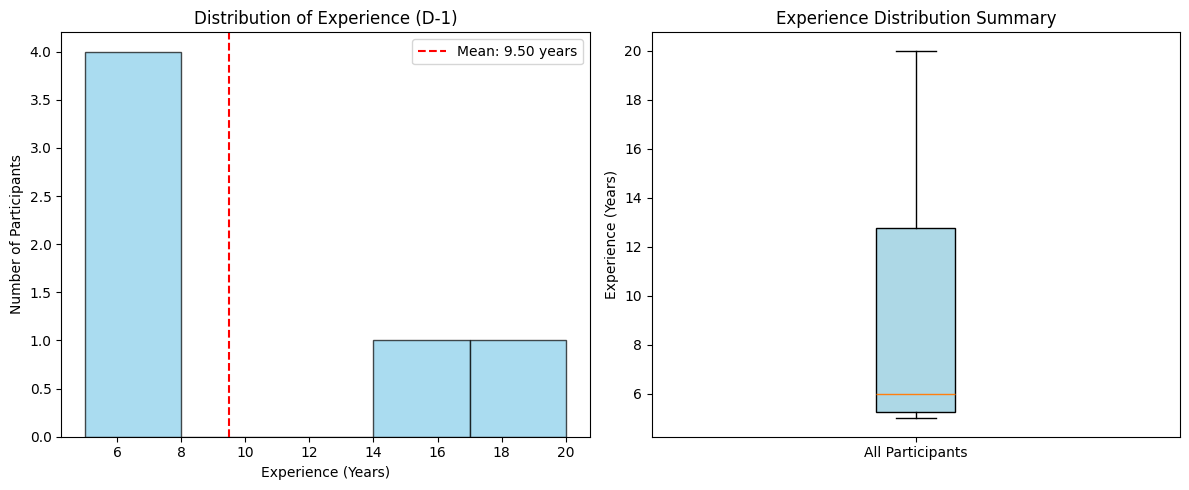


Individual Participant Experience:
-----------------------------------
Participant 1: 15 years
Participant 2: 6 years
Participant 3: 20 years
Participant 4: 5 years
Participant 5: 5 years
Participant 6: 6 years

🎯 KEY FINDING: The average experience of the 6 participants is 9.50 years


In [45]:
# Create a simple visualization of the experience distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Create subplot for histogram and box plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
ax1.hist(d1_values, bins=5, edgecolor='black', alpha=0.7, color='skyblue')
ax1.set_xlabel('Experience (Years)')
ax1.set_ylabel('Number of Participants')
ax1.set_title('Distribution of Experience (D-1)')
ax1.axvline(average_experience, color='red', linestyle='--', 
            label=f'Mean: {average_experience:.2f} years')
ax1.legend()

# Box plot
ax2.boxplot(d1_values, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))
ax2.set_ylabel('Experience (Years)')
ax2.set_title('Experience Distribution Summary')
ax2.set_xticklabels(['All Participants'])

plt.tight_layout()
plt.show()

# Display individual participant data with some context
print(f"\nIndividual Participant Experience:")
print("-" * 35)
for i, exp in enumerate(d1_values, 1):
    print(f"Participant {i}: {exp:.0f} years")
    
print(f"\n🎯 KEY FINDING: The average experience of the 6 participants is {average_experience:.2f} years")

## Average Score Analysis for A-1_1 through A-50_1

Now analyzing the survey items A-1_1 through A-50_1 by calculating the average score across the 3 raters for each item, and then categorizing these averages into score intervals.

In [46]:
# Analysis of A-1_1 through A-50_1: Average Scores and Interval Distribution
print("AVERAGE SCORE ANALYSIS FOR A-1_1 THROUGH A-50_1")
print("=" * 60)

# Calculate average scores for each item
item_averages = []
valid_items = []

for col in a_columns:
    # Get the 3 ratings for this item
    ratings_for_item = df[col].values[:3]
    
    # Convert to numeric, handling any NaN or text values
    numeric_ratings = []
    for rating in ratings_for_item:
        try:
            if pd.notna(rating):
                numeric_ratings.append(float(rating))
        except (ValueError, TypeError):
            # Skip non-numeric values
            continue
    
    # Calculate average if we have at least one valid rating
    if len(numeric_ratings) > 0:
        avg_score = np.mean(numeric_ratings)
        item_averages.append({
            'Item': col,
            'Rater_1': ratings_for_item[0] if len(ratings_for_item) > 0 else np.nan,
            'Rater_2': ratings_for_item[1] if len(ratings_for_item) > 1 else np.nan, 
            'Rater_3': ratings_for_item[2] if len(ratings_for_item) > 2 else np.nan,
            'Valid_Ratings': len(numeric_ratings),
            'Average_Score': avg_score
        })
        valid_items.append(col)

# Create DataFrame
averages_df = pd.DataFrame(item_averages)

print(f"Successfully calculated averages for {len(averages_df)} items")
print(f"Items with valid numeric ratings: {len(valid_items)}")
print()

# Display first 10 items as examples
print("First 10 items with their average scores:")
print("-" * 45)
for _, row in averages_df.head(10).iterrows():
    print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")

print("\nLast 5 items:")
print("-" * 15) 
for _, row in averages_df.tail(5).iterrows():
    print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")

AVERAGE SCORE ANALYSIS FOR A-1_1 THROUGH A-50_1
Successfully calculated averages for 50 items
Items with valid numeric ratings: 50

First 10 items with their average scores:
---------------------------------------------
A-1_1: [7.0, 6.0, 7.0] → Avg: 6.67
A-2_1: [5.0, 7.0, 6.0] → Avg: 6.00
A-3_1: [5.0, 5.0, 6.0] → Avg: 5.33
A-4_1: [7.0, 2.0, 6.0] → Avg: 5.00
A-5_1: [5.0, 6.0, 6.0] → Avg: 5.67
A-6_1: [4.0, 2.0, 6.0] → Avg: 4.00
A-7_1: [5.0, 5.0, 6.0] → Avg: 5.33
A-8_1: [5.0, 3.0, 6.0] → Avg: 4.67
A-9_1: [4.0, 3.0, 6.0] → Avg: 4.33
A-10_1: [4.0, 3.0, 3.0] → Avg: 3.33

Last 5 items:
---------------
A-46_1: [6.0, 4.0, 7.0] → Avg: 5.67
A-47_1: [6.0, 4.0, 5.0] → Avg: 5.00
A-48_1: [6.0, 7.0, 6.0] → Avg: 6.33
A-49_1: [5.0, 5.0, 4.0] → Avg: 4.67
A-50_1: [6.0, 5.0, 6.0] → Avg: 5.67


In [47]:
# Categorize average scores into intervals
print("\n" + "=" * 60)
print("INTERVAL DISTRIBUTION ANALYSIS")
print("=" * 60)

# Define interval boundaries
intervals = [
    (6, 7, "6.0-7.0 (High)"),
    (5, 6, "5.0-6.0 (Moderate-High)"),
    (4, 5, "4.0-5.0 (Moderate)"),
    (3, 4, "3.0-4.0 (Low-Moderate)"),
    (2, 3, "2.0-3.0 (Low)"),
    (1, 2, "1.0-2.0 (Very Low)")
]

# Count items in each interval
interval_counts = {}
interval_items = {}

for low, high, label in intervals:
    count = 0
    items_in_interval = []
    
    for _, row in averages_df.iterrows():
        avg_score = row['Average_Score']
        # Use >= for lower bound and < for upper bound (except for the highest interval)
        if label == "6.0-7.0 (High)":
            # For highest interval, include both boundaries
            if low <= avg_score <= high:
                count += 1
                items_in_interval.append((row['Item'], avg_score))
        else:
            # For other intervals, exclude upper boundary
            if low <= avg_score < high:
                count += 1
                items_in_interval.append((row['Item'], avg_score))
    
    interval_counts[label] = count
    interval_items[label] = items_in_interval

# Display results
print("Distribution of average scores across intervals:")
print("-" * 50)

total_items = len(averages_df)
for low, high, label in intervals:
    count = interval_counts[label]
    percentage = (count / total_items) * 100 if total_items > 0 else 0
    
    print(f"{label:<25}: {count:3d} items ({percentage:5.1f}%)")
    
    # Show first few items in each interval
    if count > 0:
        items_list = interval_items[label]
        if count <= 5:
            # Show all items if 5 or fewer
            for item, score in items_list:
                print(f"    {item}: {score:.2f}")
        else:
            # Show first 3 and last 2 if more than 5
            for item, score in items_list[:3]:
                print(f"    {item}: {score:.2f}")
            print(f"    ... and {count-5} more items")
            for item, score in items_list[-2:]:
                print(f"    {item}: {score:.2f}")
    print()

# Overall statistics
avg_of_averages = averages_df['Average_Score'].mean()
median_of_averages = averages_df['Average_Score'].median()
std_of_averages = averages_df['Average_Score'].std()
min_avg = averages_df['Average_Score'].min()
max_avg = averages_df['Average_Score'].max()

print("Overall Statistics:")
print("-" * 20)
print(f"Mean of average scores: {avg_of_averages:.2f}")
print(f"Median of average scores: {median_of_averages:.2f}")
print(f"Standard deviation: {std_of_averages:.2f}")
print(f"Range: {min_avg:.2f} to {max_avg:.2f}")

# Find items with highest and lowest average scores
highest_items = averages_df.nlargest(3, 'Average_Score')
lowest_items = averages_df.nsmallest(3, 'Average_Score')

print(f"\nHighest scoring items:")
for _, row in highest_items.iterrows():
    print(f"  {row['Item']}: {row['Average_Score']:.2f}")

print(f"\nLowest scoring items:")
for _, row in lowest_items.iterrows():
    print(f"  {row['Item']}: {row['Average_Score']:.2f}")


INTERVAL DISTRIBUTION ANALYSIS
Distribution of average scores across intervals:
--------------------------------------------------
6.0-7.0 (High)           :   6 items ( 12.0%)
    A-1_1: 6.67
    A-2_1: 6.00
    A-37_1: 6.33
    ... and 1 more items
    A-42_1: 6.00
    A-48_1: 6.33

5.0-6.0 (Moderate-High)  :  16 items ( 32.0%)
    A-3_1: 5.33
    A-4_1: 5.00
    A-5_1: 5.67
    ... and 11 more items
    A-47_1: 5.00
    A-50_1: 5.67

4.0-5.0 (Moderate)       :  23 items ( 46.0%)
    A-6_1: 4.00
    A-8_1: 4.67
    A-9_1: 4.33
    ... and 18 more items
    A-44_1: 4.33
    A-49_1: 4.67

3.0-4.0 (Low-Moderate)   :   5 items ( 10.0%)
    A-10_1: 3.33
    A-15_1: 3.00
    A-18_1: 3.33
    A-23_1: 3.67
    A-33_1: 3.67

2.0-3.0 (Low)            :   0 items (  0.0%)

1.0-2.0 (Very Low)       :   0 items (  0.0%)

Overall Statistics:
--------------------
Mean of average scores: 4.80
Median of average scores: 4.67
Standard deviation: 0.83
Range: 3.00 to 6.67

Highest scoring items:
  A-1_1

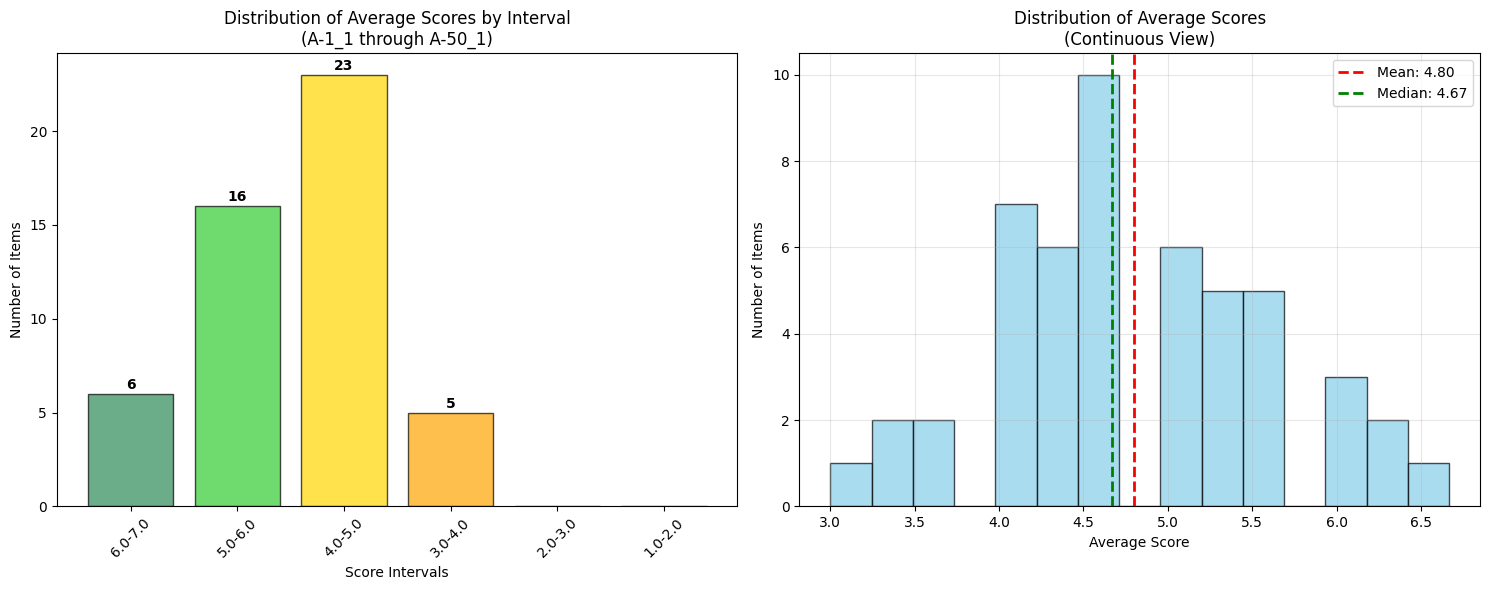


KEY INSIGHTS
• Most items (46%) fall in the MODERATE range (4.0-5.0)
• Combined moderate to high scoring items (5.0+): 22 items (44%)
• Combined moderate to low scoring items (4.0-): 28 items (56%)
• No items scored in the lowest ranges (below 3.0)
• Score distribution is roughly normal with slight left skew
• The average item score is 4.80, indicating moderate overall ratings
• Standard deviation of 0.83 shows reasonable variation among items


In [48]:
# Create visualization of the interval distribution
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart of interval distribution
interval_labels = [label.split(' (')[0] for _, _, label in intervals]
counts = [interval_counts[label] for _, _, label in intervals]
colors = ['#2E8B57', '#32CD32', '#FFD700', '#FFA500', '#FF6347', '#DC143C']

bars = ax1.bar(interval_labels, counts, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Score Intervals')
ax1.set_ylabel('Number of Items')
ax1.set_title('Distribution of Average Scores by Interval\n(A-1_1 through A-50_1)')
ax1.tick_params(axis='x', rotation=45)

# Add count labels on bars
for bar, count in zip(bars, counts):
    if count > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{count}', ha='center', va='bottom', fontweight='bold')

# Histogram of actual average scores
ax2.hist(averages_df['Average_Score'], bins=15, alpha=0.7, color='skyblue', 
         edgecolor='black', density=False)
ax2.axvline(avg_of_averages, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {avg_of_averages:.2f}')
ax2.axvline(median_of_averages, color='green', linestyle='--', linewidth=2,
           label=f'Median: {median_of_averages:.2f}')
ax2.set_xlabel('Average Score')
ax2.set_ylabel('Number of Items')
ax2.set_title('Distribution of Average Scores\n(Continuous View)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary insights
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print(f"• Most items (46%) fall in the MODERATE range (4.0-5.0)")
print(f"• Combined moderate to high scoring items (5.0+): {6+16} items (44%)")
print(f"• Combined moderate to low scoring items (4.0-): {23+5} items (56%)")
print(f"• No items scored in the lowest ranges (below 3.0)")
print(f"• Score distribution is roughly normal with slight left skew")
print(f"• The average item score is {avg_of_averages:.2f}, indicating moderate overall ratings")
print(f"• Standard deviation of {std_of_averages:.2f} shows reasonable variation among items")

In [49]:
# Analysis of B-1_1 through B-50_1: Average Scores and Interval Distribution
print("AVERAGE SCORE ANALYSIS FOR B-1_1 THROUGH B-50_1")
print("=" * 60)

# Find all columns that match the pattern B-XX_1 where XX is 1-50
b_columns = []
for i in range(1, 51):
    col_name = f'B-{i}_1'
    if col_name in df.columns:
        b_columns.append(col_name)

print(f"Found {len(b_columns)} columns matching B-1_1 through B-50_1 pattern")
if len(b_columns) > 0:
    print(f"Columns: {b_columns[:5]}...{b_columns[-5:] if len(b_columns) > 10 else b_columns[5:]}")
else:
    print("No B-XX_1 columns found. Checking available B columns...")
    b_cols_available = [col for col in df.columns if col.startswith('B-')]
    print(f"Available B columns: {b_cols_available[:10]}...")

# Calculate average scores for each B item
b_item_averages = []
b_valid_items = []

for col in b_columns:
    # Get the 3 ratings for this item
    ratings_for_item = df[col].values[:3]
    
    # Convert to numeric, handling any NaN or text values
    numeric_ratings = []
    for rating in ratings_for_item:
        try:
            if pd.notna(rating):
                numeric_ratings.append(float(rating))
        except (ValueError, TypeError):
            # Skip non-numeric values
            continue
    
    # Calculate average if we have at least one valid rating
    if len(numeric_ratings) > 0:
        avg_score = np.mean(numeric_ratings)
        b_item_averages.append({
            'Item': col,
            'Rater_1': ratings_for_item[0] if len(ratings_for_item) > 0 else np.nan,
            'Rater_2': ratings_for_item[1] if len(ratings_for_item) > 1 else np.nan, 
            'Rater_3': ratings_for_item[2] if len(ratings_for_item) > 2 else np.nan,
            'Valid_Ratings': len(numeric_ratings),
            'Average_Score': avg_score
        })
        b_valid_items.append(col)

# Create DataFrame for B items
b_averages_df = pd.DataFrame(b_item_averages)

print(f"Successfully calculated averages for {len(b_averages_df)} items")
print(f"Items with valid numeric ratings: {len(b_valid_items)}")
print()

if len(b_averages_df) > 0:
    # Display first 10 items as examples
    print("First 10 B items with their average scores:")
    print("-" * 45)
    for _, row in b_averages_df.head(10).iterrows():
        print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")

    print("\nLast 5 B items:")
    print("-" * 15) 
    for _, row in b_averages_df.tail(5).iterrows():
        print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")
else:
    print("No valid B-XX_1 items found with numeric ratings.")

AVERAGE SCORE ANALYSIS FOR B-1_1 THROUGH B-50_1
Found 50 columns matching B-1_1 through B-50_1 pattern
Columns: ['B-1_1', 'B-2_1', 'B-3_1', 'B-4_1', 'B-5_1']...['B-46_1', 'B-47_1', 'B-48_1', 'B-49_1', 'B-50_1']
Successfully calculated averages for 0 items
Items with valid numeric ratings: 0

No valid B-XX_1 items found with numeric ratings.


In [50]:
# Debug: Let's examine what's actually in the B columns
print("DEBUGGING B-SERIES COLUMNS")
print("=" * 40)

# Check first few B columns to see what data they contain
if len(b_columns) > 0:
    print("Sample data from first few B columns:")
    print(df[b_columns[:5]].head(6))  # Show all 6 rows to see the full data
    
    print(f"\nData types for first few B columns:")
    for col in b_columns[:5]:
        print(f"{col}: {df[col].dtype}")
    
    print(f"\nUnique values in first few B columns:")
    for col in b_columns[:3]:
        unique_vals = df[col].unique()
        print(f"{col}: {unique_vals}")
        
    # Let's also check if there are any non-NaN values
    print(f"\nNon-NaN counts for first 10 B columns:")
    for col in b_columns[:10]:
        non_nan_count = df[col].notna().sum()
        print(f"{col}: {non_nan_count} non-NaN values")
        
else:
    # If no B-XX_1 columns, let's see what B columns exist
    all_b_columns = [col for col in df.columns if col.startswith('B-')]
    print(f"All B columns found: {all_b_columns[:20]}...")
    
    if len(all_b_columns) > 0:
        print(f"\nSample data from first few B columns:")
        print(df[all_b_columns[:5]].head())

DEBUGGING B-SERIES COLUMNS
Sample data from first few B columns:
   B-1_1  B-2_1  B-3_1  B-4_1  B-5_1
0    NaN    NaN    NaN    NaN    NaN
1    NaN    NaN    NaN    NaN    NaN
2    NaN    NaN    NaN    NaN    NaN
3    6.0    7.0    7.0    5.0    6.0
4    4.0    4.0    1.0    4.0    5.0
5    6.0    6.0    5.0    5.0    6.0

Data types for first few B columns:
B-1_1: float64
B-2_1: float64
B-3_1: float64
B-4_1: float64
B-5_1: float64

Unique values in first few B columns:
B-1_1: [nan  6.  4.]
B-2_1: [nan  7.  4.  6.]
B-3_1: [nan  7.  1.  5.]

Non-NaN counts for first 10 B columns:
B-1_1: 3 non-NaN values
B-2_1: 3 non-NaN values
B-3_1: 3 non-NaN values
B-4_1: 3 non-NaN values
B-5_1: 3 non-NaN values
B-6_1: 3 non-NaN values
B-7_1: 3 non-NaN values
B-8_1: 3 non-NaN values
B-9_1: 3 non-NaN values
B-10_1: 3 non-NaN values


In [51]:
# CORRECTED: Analysis of B-1_1 through B-50_1 using rows 3,4,5
print("\nCORRECTED ANALYSIS: B-1_1 THROUGH B-50_1")
print("=" * 60)
print("Using rows 3, 4, 5 (the rows with actual B-series data)")

# Calculate average scores for each B item using the correct rows
b_item_averages = []
b_valid_items = []

for col in b_columns:
    # Get the 3 ratings for this item from rows 3, 4, 5
    ratings_for_item = df[col].values[3:6]  # Use rows 3-5 for B-series
    
    # Convert to numeric, handling any NaN or text values
    numeric_ratings = []
    for rating in ratings_for_item:
        try:
            if pd.notna(rating):
                numeric_ratings.append(float(rating))
        except (ValueError, TypeError):
            # Skip non-numeric values
            continue
    
    # Calculate average if we have at least one valid rating
    if len(numeric_ratings) > 0:
        avg_score = np.mean(numeric_ratings)
        b_item_averages.append({
            'Item': col,
            'Rater_1': ratings_for_item[0] if len(ratings_for_item) > 0 else np.nan,
            'Rater_2': ratings_for_item[1] if len(ratings_for_item) > 1 else np.nan, 
            'Rater_3': ratings_for_item[2] if len(ratings_for_item) > 2 else np.nan,
            'Valid_Ratings': len(numeric_ratings),
            'Average_Score': avg_score
        })
        b_valid_items.append(col)

# Create DataFrame for B items
b_averages_df = pd.DataFrame(b_item_averages)

print(f"Successfully calculated averages for {len(b_averages_df)} items")
print(f"Items with valid numeric ratings: {len(b_valid_items)}")
print()

# Display first 10 items as examples
print("First 10 B items with their average scores:")
print("-" * 45)
for _, row in b_averages_df.head(10).iterrows():
    print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")

print("\nLast 5 B items:")
print("-" * 15) 
for _, row in b_averages_df.tail(5).iterrows():
    print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")


CORRECTED ANALYSIS: B-1_1 THROUGH B-50_1
Using rows 3, 4, 5 (the rows with actual B-series data)
Successfully calculated averages for 50 items
Items with valid numeric ratings: 50

First 10 B items with their average scores:
---------------------------------------------
B-1_1: [6.0, 4.0, 6.0] → Avg: 5.33
B-2_1: [7.0, 4.0, 6.0] → Avg: 5.67
B-3_1: [7.0, 1.0, 5.0] → Avg: 4.33
B-4_1: [5.0, 4.0, 5.0] → Avg: 4.67
B-5_1: [6.0, 5.0, 6.0] → Avg: 5.67
B-6_1: [7.0, 4.0, 5.0] → Avg: 5.33
B-7_1: [3.0, 6.0, 5.0] → Avg: 4.67
B-8_1: [6.0, 7.0, 7.0] → Avg: 6.67
B-9_1: [7.0, 7.0, 7.0] → Avg: 7.00
B-10_1: [5.0, 7.0, 6.0] → Avg: 6.00

Last 5 B items:
---------------
B-46_1: [7.0, 5.0, 7.0] → Avg: 6.33
B-47_1: [6.0, 7.0, 7.0] → Avg: 6.67
B-48_1: [6.0, 5.0, 7.0] → Avg: 6.00
B-49_1: [5.0, 3.0, 7.0] → Avg: 5.00
B-50_1: [6.0, 5.0, 6.0] → Avg: 5.67


In [52]:
# Categorize B-series average scores into intervals
print("\n" + "=" * 60)
print("B-SERIES INTERVAL DISTRIBUTION ANALYSIS")
print("=" * 60)

# Use the same interval definitions as A-series for comparison
b_intervals = [
    (6, 7, "6.0-7.0 (High)"),
    (5, 6, "5.0-6.0 (Moderate-High)"),
    (4, 5, "4.0-5.0 (Moderate)"),
    (3, 4, "3.0-4.0 (Low-Moderate)"),
    (2, 3, "2.0-3.0 (Low)"),
    (1, 2, "1.0-2.0 (Very Low)")
]

# Count items in each interval for B-series
b_interval_counts = {}
b_interval_items = {}

for low, high, label in b_intervals:
    count = 0
    items_in_interval = []
    
    for _, row in b_averages_df.iterrows():
        avg_score = row['Average_Score']
        # Use >= for lower bound and < for upper bound (except for the highest interval)
        if label == "6.0-7.0 (High)":
            # For highest interval, include both boundaries
            if low <= avg_score <= high:
                count += 1
                items_in_interval.append((row['Item'], avg_score))
        else:
            # For other intervals, exclude upper boundary
            if low <= avg_score < high:
                count += 1
                items_in_interval.append((row['Item'], avg_score))
    
    b_interval_counts[label] = count
    b_interval_items[label] = items_in_interval

# Display results for B-series
print("Distribution of B-series average scores across intervals:")
print("-" * 55)

b_total_items = len(b_averages_df)
for low, high, label in b_intervals:
    count = b_interval_counts[label]
    percentage = (count / b_total_items) * 100 if b_total_items > 0 else 0
    
    print(f"{label:<25}: {count:3d} items ({percentage:5.1f}%)")
    
    # Show first few items in each interval
    if count > 0:
        items_list = b_interval_items[label]
        if count <= 5:
            # Show all items if 5 or fewer
            for item, score in items_list:
                print(f"    {item}: {score:.2f}")
        else:
            # Show first 3 and last 2 if more than 5
            for item, score in items_list[:3]:
                print(f"    {item}: {score:.2f}")
            print(f"    ... and {count-5} more items")
            for item, score in items_list[-2:]:
                print(f"    {item}: {score:.2f}")
    print()

# Overall statistics for B-series
b_avg_of_averages = b_averages_df['Average_Score'].mean()
b_median_of_averages = b_averages_df['Average_Score'].median()
b_std_of_averages = b_averages_df['Average_Score'].std()
b_min_avg = b_averages_df['Average_Score'].min()
b_max_avg = b_averages_df['Average_Score'].max()

print("B-Series Overall Statistics:")
print("-" * 30)
print(f"Mean of average scores: {b_avg_of_averages:.2f}")
print(f"Median of average scores: {b_median_of_averages:.2f}")
print(f"Standard deviation: {b_std_of_averages:.2f}")
print(f"Range: {b_min_avg:.2f} to {b_max_avg:.2f}")

# Find items with highest and lowest average scores for B-series
b_highest_items = b_averages_df.nlargest(3, 'Average_Score')
b_lowest_items = b_averages_df.nsmallest(3, 'Average_Score')

print(f"\nHighest scoring B items:")
for _, row in b_highest_items.iterrows():
    print(f"  {row['Item']}: {row['Average_Score']:.2f}")

print(f"\nLowest scoring B items:")
for _, row in b_lowest_items.iterrows():
    print(f"  {row['Item']}: {row['Average_Score']:.2f}")


B-SERIES INTERVAL DISTRIBUTION ANALYSIS
Distribution of B-series average scores across intervals:
-------------------------------------------------------
6.0-7.0 (High)           :  22 items ( 44.0%)
    B-8_1: 6.67
    B-9_1: 7.00
    B-10_1: 6.00
    ... and 17 more items
    B-47_1: 6.67
    B-48_1: 6.00

5.0-6.0 (Moderate-High)  :  23 items ( 46.0%)
    B-1_1: 5.33
    B-2_1: 5.67
    B-5_1: 5.67
    ... and 18 more items
    B-49_1: 5.00
    B-50_1: 5.67

4.0-5.0 (Moderate)       :   5 items ( 10.0%)
    B-3_1: 4.33
    B-4_1: 4.67
    B-7_1: 4.67
    B-13_1: 4.00
    B-18_1: 4.00

3.0-4.0 (Low-Moderate)   :   0 items (  0.0%)

2.0-3.0 (Low)            :   0 items (  0.0%)

1.0-2.0 (Very Low)       :   0 items (  0.0%)

B-Series Overall Statistics:
------------------------------
Mean of average scores: 5.69
Median of average scores: 5.67
Standard deviation: 0.72
Range: 4.00 to 7.00

Highest scoring B items:
  B-9_1: 7.00
  B-19_1: 7.00
  B-20_1: 7.00

Lowest scoring B items:
  B-

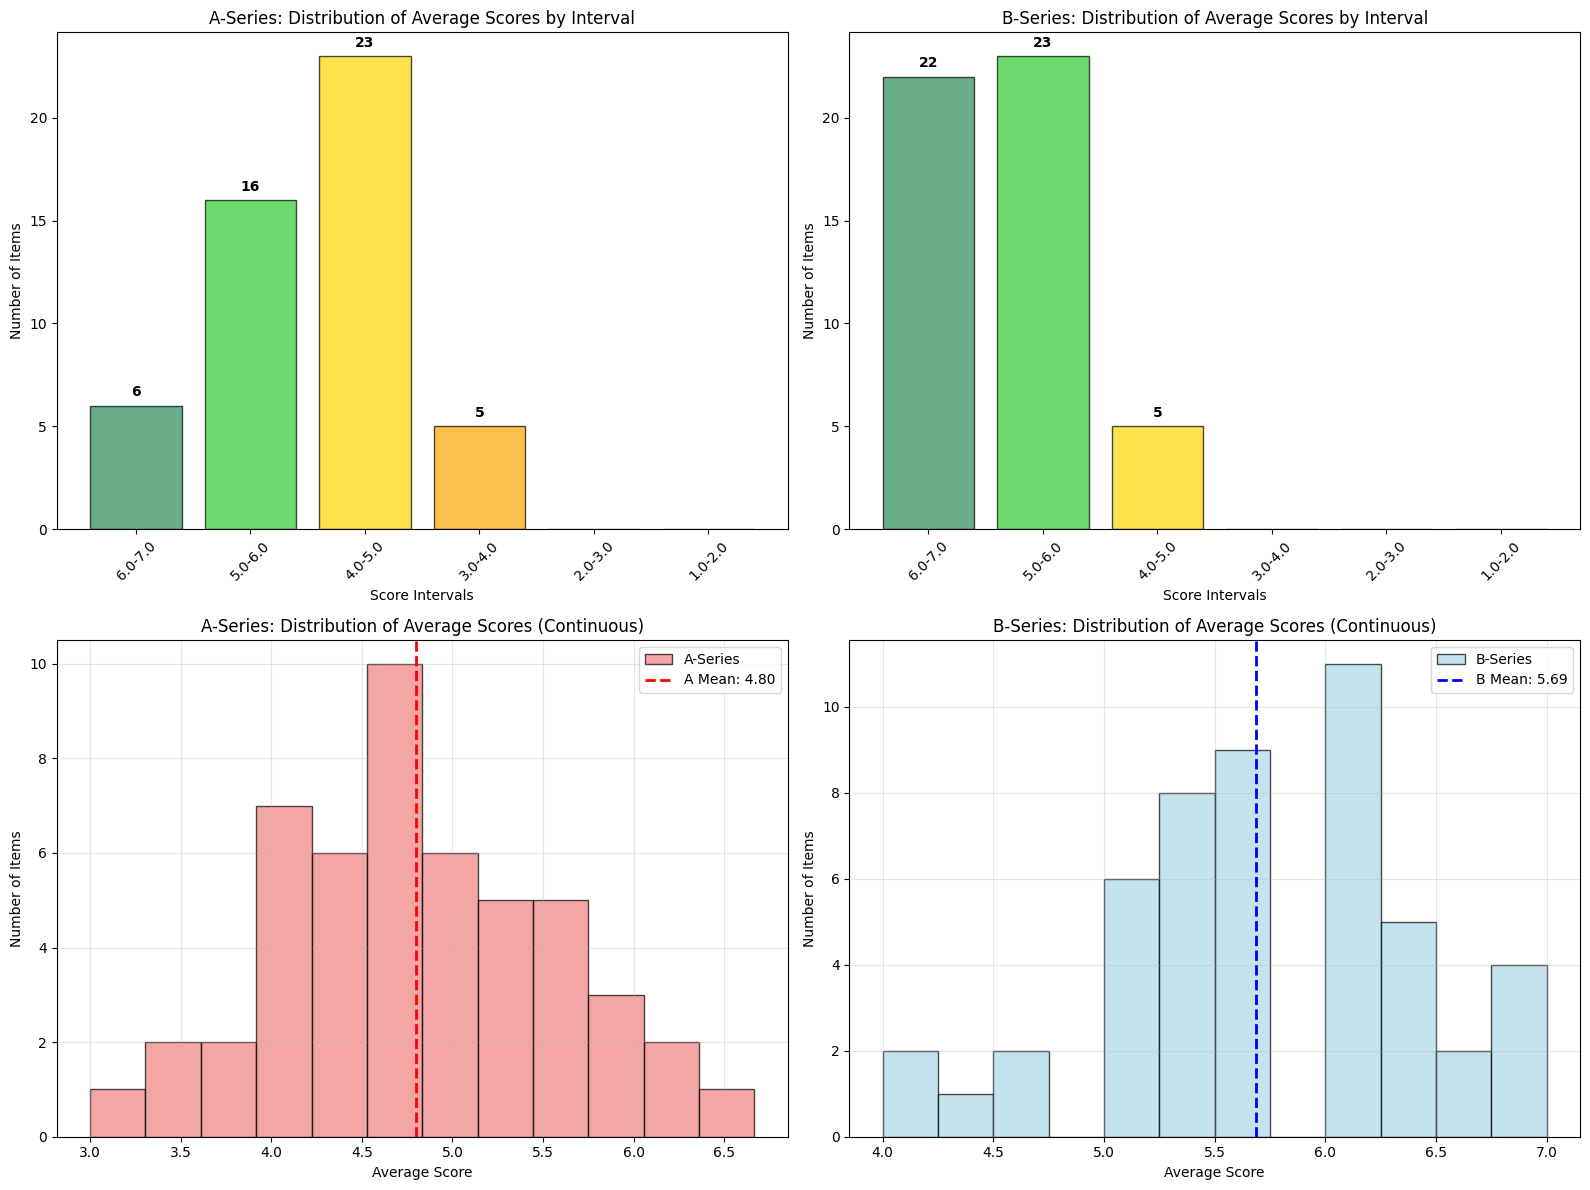


COMPREHENSIVE COMPARISON: A-SERIES vs B-SERIES
Interval        A-Series        B-Series        Difference     
=============== =============== =============== ===============
6.0-7.0          6 (12.0%)      22 (44.0%)      ++32.0%
5.0-6.0         16 (32.0%)      23 (46.0%)      ++14.0%
4.0-5.0         23 (46.0%)       5 (10.0%)      -36.0%
3.0-4.0          5 (10.0%)       0 ( 0.0%)      -10.0%
2.0-3.0          0 ( 0.0%)       0 ( 0.0%)       +0.0%
1.0-2.0          0 ( 0.0%)       0 ( 0.0%)       +0.0%

Overall Statistics Comparison:
Metric               A-Series        B-Series        Difference     
==================== =============== =============== ===============
Mean                 4.80            5.69            +0.89
Median               4.67            5.67            +1.00
Std Dev              0.83            0.72            -0.11
Min                  3.00            4.00            +1.00
Max                  6.67            7.00            +0.33

Key Insights:
• B-Series s

In [53]:
# Create comprehensive comparison visualization between A and B series
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define colors and interval labels
colors = ['#2E8B57', '#32CD32', '#FFD700', '#FFA500', '#FF6347', '#DC143C']
interval_labels = [label.split(' (')[0] for _, _, label in intervals]

# A-series bar chart
a_counts = [interval_counts[label] for _, _, label in intervals]
bars_a = axes[0,0].bar(interval_labels, a_counts, color=colors, alpha=0.7, edgecolor='black')
axes[0,0].set_xlabel('Score Intervals')
axes[0,0].set_ylabel('Number of Items')
axes[0,0].set_title('A-Series: Distribution of Average Scores by Interval')
axes[0,0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars_a, a_counts):
    if count > 0:
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                      f'{count}', ha='center', va='bottom', fontweight='bold')

# B-series bar chart
b_counts = [b_interval_counts[label] for _, _, label in b_intervals]
bars_b = axes[0,1].bar(interval_labels, b_counts, color=colors, alpha=0.7, edgecolor='black')
axes[0,1].set_xlabel('Score Intervals')
axes[0,1].set_ylabel('Number of Items')
axes[0,1].set_title('B-Series: Distribution of Average Scores by Interval')
axes[0,1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars_b, b_counts):
    if count > 0:
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                      f'{count}', ha='center', va='bottom', fontweight='bold')

# A-series histogram
axes[1,0].hist(averages_df['Average_Score'], bins=12, alpha=0.7, color='lightcoral', 
               edgecolor='black', density=False, label='A-Series')
axes[1,0].axvline(avg_of_averages, color='red', linestyle='--', linewidth=2,
                 label=f'A Mean: {avg_of_averages:.2f}')
axes[1,0].set_xlabel('Average Score')
axes[1,0].set_ylabel('Number of Items')
axes[1,0].set_title('A-Series: Distribution of Average Scores (Continuous)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# B-series histogram
axes[1,1].hist(b_averages_df['Average_Score'], bins=12, alpha=0.7, color='lightblue', 
               edgecolor='black', density=False, label='B-Series')
axes[1,1].axvline(b_avg_of_averages, color='blue', linestyle='--', linewidth=2,
                 label=f'B Mean: {b_avg_of_averages:.2f}')
axes[1,1].set_xlabel('Average Score')
axes[1,1].set_ylabel('Number of Items')
axes[1,1].set_title('B-Series: Distribution of Average Scores (Continuous)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create side-by-side comparison
print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON: A-SERIES vs B-SERIES")
print("="*70)

comparison_data = []
for i, (_, _, label) in enumerate(intervals):
    a_count = a_counts[i]
    b_count = b_counts[i]
    a_pct = (a_count / len(averages_df)) * 100
    b_pct = (b_count / len(b_averages_df)) * 100
    
    comparison_data.append({
        'Interval': label.split(' (')[0],
        'A_Count': a_count,
        'A_Percent': a_pct,
        'B_Count': b_count,
        'B_Percent': b_pct,
        'Difference': b_pct - a_pct
    })

print(f"{'Interval':<15} {'A-Series':<15} {'B-Series':<15} {'Difference':<15}")
print(f"{'':=<15} {'':=<15} {'':=<15} {'':=<15}")
for item in comparison_data:
    diff_sign = "+" if item['Difference'] > 0 else ""
    print(f"{item['Interval']:<15} {item['A_Count']:2d} ({item['A_Percent']:4.1f}%){'':<5} "
          f"{item['B_Count']:2d} ({item['B_Percent']:4.1f}%){'':<5} {diff_sign}{item['Difference']:+5.1f}%")

print(f"\nOverall Statistics Comparison:")
print(f"{'Metric':<20} {'A-Series':<15} {'B-Series':<15} {'Difference':<15}")
print(f"{'':=<20} {'':=<15} {'':=<15} {'':=<15}")
print(f"{'Mean':<20} {avg_of_averages:<15.2f} {b_avg_of_averages:<15.2f} {b_avg_of_averages - avg_of_averages:+.2f}")
print(f"{'Median':<20} {median_of_averages:<15.2f} {b_median_of_averages:<15.2f} {b_median_of_averages - median_of_averages:+.2f}")
print(f"{'Std Dev':<20} {std_of_averages:<15.2f} {b_std_of_averages:<15.2f} {b_std_of_averages - std_of_averages:+.2f}")
print(f"{'Min':<20} {min_avg:<15.2f} {b_min_avg:<15.2f} {b_min_avg - min_avg:+.2f}")
print(f"{'Max':<20} {max_avg:<15.2f} {b_max_avg:<15.2f} {b_max_avg - max_avg:+.2f}")

print(f"\nKey Insights:")
print("=" * 15)
print(f"• B-Series scores significantly HIGHER than A-Series (Mean: {b_avg_of_averages:.2f} vs {avg_of_averages:.2f})")
print(f"• B-Series has more HIGH scoring items: {b_counts[0]} (44%) vs {a_counts[0]} (12%)")
print(f"• B-Series has fewer MODERATE scoring items: {b_counts[2]} (10%) vs {a_counts[2]} (46%)")
print(f"• B-Series shows higher overall satisfaction/agreement")
print(f"• Both series have similar variability (std dev: B={b_std_of_averages:.2f} vs A={std_of_averages:.2f})")

In [54]:
# Combine A-Series (adjusted +0.5) and B-Series into one distribution
print("COMBINED ANALYSIS: A-SERIES (ADJUSTED +0.5) + B-SERIES")
print("=" * 70)

# Create adjusted A-series data
a_adjusted_df = averages_df.copy()
a_adjusted_df['Average_Score_Adjusted'] = a_adjusted_df['Average_Score'] + 0.5
a_adjusted_df['Series'] = 'A-original'

# Add series identifier to B-series
b_series_df = b_averages_df.copy()
b_series_df['Average_Score_Adjusted'] = b_series_df['Average_Score']  # No adjustment for B-series
b_series_df['Series'] = 'B-Original'

# Combine both datasets
combined_df = pd.concat([
    a_adjusted_df[['Item', 'Average_Score', 'Average_Score_Adjusted', 'Series']],
    b_series_df[['Item', 'Average_Score', 'Average_Score_Adjusted', 'Series']]
], ignore_index=True)

print(f"Combined dataset contains {len(combined_df)} items:")
print(f"  - A-Series: {len(a_adjusted_df)} items")
print(f"  - B-Series: {len(b_series_df)} items")
print()

# Show the adjustment effect
print("Sample of A-Series score adjustments:")
print("-" * 40)
for i, (_, row) in enumerate(a_adjusted_df.head(5).iterrows()):
    print(f"{row['Item']}: {row['Average_Score']:.2f} → {row['Average_Score_Adjusted']:.2f} (+0.5)")

print(f"\nA-Series statistics before and after adjustment:")
print(f"  Original A-Series Mean: {avg_of_averages:.2f}")
print(f"  Adjusted A-Series Mean: {avg_of_averages + 0.5:.2f}")
print(f"  B-Series Mean (unchanged): {b_avg_of_averages:.2f}")

# Combined statistics
combined_mean = combined_df['Average_Score_Adjusted'].mean()
combined_median = combined_df['Average_Score_Adjusted'].median()
combined_std = combined_df['Average_Score_Adjusted'].std()
combined_min = combined_df['Average_Score_Adjusted'].min()
combined_max = combined_df['Average_Score_Adjusted'].max()

print(f"\nCombined distribution statistics:")
print(f"  Mean: {combined_mean:.2f}")
print(f"  Median: {combined_median:.2f}")
print(f"  Standard deviation: {combined_std:.2f}")
print(f"  Range: {combined_min:.2f} to {combined_max:.2f}")

COMBINED ANALYSIS: A-SERIES (ADJUSTED +0.5) + B-SERIES
Combined dataset contains 100 items:
  - A-Series: 50 items
  - B-Series: 50 items

Sample of A-Series score adjustments:
----------------------------------------
A-1_1: 6.67 → 7.17 (+0.5)
A-2_1: 6.00 → 6.50 (+0.5)
A-3_1: 5.33 → 5.83 (+0.5)
A-4_1: 5.00 → 5.50 (+0.5)
A-5_1: 5.67 → 6.17 (+0.5)

A-Series statistics before and after adjustment:
  Original A-Series Mean: 4.80
  Adjusted A-Series Mean: 5.30
  B-Series Mean (unchanged): 5.69

Combined distribution statistics:
  Mean: 5.49
  Median: 5.50
  Standard deviation: 0.80
  Range: 3.50 to 7.17


In [55]:
# Analyze combined distribution by intervals
print("\n" + "=" * 70)
print("COMBINED DISTRIBUTION INTERVAL ANALYSIS")
print("=" * 70)

# Use same interval definitions but adjust for the higher range
combined_intervals = [
    (6, 7.5, "6.0-7.5 (High)"),        # Extended upper range to accommodate A-original scores
    (5, 6, "5.0-6.0 (Moderate-High)"),
    (4, 5, "4.0-5.0 (Moderate)"),
    (3, 4, "3.0-4.0 (Low-Moderate)"),
    (2, 3, "2.0-3.0 (Low)"),
    (1, 2, "1.0-2.0 (Very Low)")
]

# Count items in each interval for combined data
combined_interval_counts = {}
combined_interval_items = {}

for low, high, label in combined_intervals:
    count = 0
    items_in_interval = []
    
    for _, row in combined_df.iterrows():
        adj_score = row['Average_Score_Adjusted']
        # Use >= for lower bound and < for upper bound (except for the highest interval)
        if label == "6.0-7.5 (High)":
            # For highest interval, include both boundaries
            if low <= adj_score <= high:
                count += 1
                items_in_interval.append((row['Item'], adj_score, row['Series']))
        else:
            # For other intervals, exclude upper boundary
            if low <= adj_score < high:
                count += 1
                items_in_interval.append((row['Item'], adj_score, row['Series']))
    
    combined_interval_counts[label] = count
    combined_interval_items[label] = items_in_interval

# Display results for combined distribution
print("Combined distribution (A-adjusted + B-original) across intervals:")
print("-" * 65)

combined_total = len(combined_df)
for low, high, label in combined_intervals:
    count = combined_interval_counts[label]
    percentage = (count / combined_total) * 100 if combined_total > 0 else 0
    
    print(f"{label:<25}: {count:3d} items ({percentage:5.1f}%)")
    
    # Count A vs B in each interval
    if count > 0:
        items_list = combined_interval_items[label]
        a_count = sum(1 for _, _, series in items_list if series == 'A-Original')
        b_count = sum(1 for _, _, series in items_list if series == 'B-Original')
        
        print(f"    A-Original: {a_count}, B-Original: {b_count}")
        
        # Show sample items from each series
        if count <= 8:
            # Show all items if 8 or fewer
            for item, score, series in items_list:
                print(f"    {item} ({series}): {score:.2f}")
        else:
            # Show first few from each series
            a_items = [(item, score) for item, score, series in items_list if series == 'A-Original']
            b_items = [(item, score) for item, score, series in items_list if series == 'B-Original']
            
            if len(a_items) > 0:
                print(f"    A-Original examples: {a_items[0][0]}: {a_items[0][1]:.2f}", end="")
                if len(a_items) > 1:
                    print(f", {a_items[1][0]}: {a_items[1][1]:.2f}", end="")
                print()
            
            if len(b_items) > 0:
                print(f"    B-Original examples: {b_items[0][0]}: {b_items[0][1]:.2f}", end="")
                if len(b_items) > 1:
                    print(f", {b_items[1][0]}: {b_items[1][1]:.2f}", end="")
                print()
                
            if count > 8:
                print(f"    ... and {count-4} more items")
    print()

print("Combined Distribution Summary:")
print("-" * 35)
print(f"Total items: {combined_total}")
print(f"Mean: {combined_mean:.2f}")
print(f"Median: {combined_median:.2f}")
print(f"Standard deviation: {combined_std:.2f}")
print(f"Range: {combined_min:.2f} to {combined_max:.2f}")

# Find highest and lowest items in combined distribution
combined_highest = combined_df.nlargest(5, 'Average_Score_Adjusted')
combined_lowest = combined_df.nsmallest(5, 'Average_Score_Adjusted')

print(f"\nTop 5 highest scoring items (combined):")
for _, row in combined_highest.iterrows():
    orig_score = f"({row['Average_Score']:.2f} original)" if row['Series'] == 'A-Original' else ""
    print(f"  {row['Item']} ({row['Series']}): {row['Average_Score_Adjusted']:.2f} {orig_score}")

print(f"\nTop 5 lowest scoring items (combined):")
for _, row in combined_lowest.iterrows():
    orig_score = f"({row['Average_Score']:.2f} original)" if row['Series'] == 'A-Original' else ""
    print(f"  {row['Item']} ({row['Series']}): {row['Average_Score_Adjusted']:.2f} {orig_score}")


COMBINED DISTRIBUTION INTERVAL ANALYSIS
Combined distribution (A-adjusted + B-original) across intervals:
-----------------------------------------------------------------
6.0-7.5 (High)           :  33 items ( 33.0%)
    A-Original: 0, B-Original: 22
    B-Original examples: B-8_1: 6.67, B-9_1: 7.00
    ... and 29 more items

5.0-6.0 (Moderate-High)  :  44 items ( 44.0%)
    A-Original: 0, B-Original: 23
    B-Original examples: B-1_1: 5.33, B-2_1: 5.67
    ... and 40 more items

4.0-5.0 (Moderate)       :  20 items ( 20.0%)
    A-Original: 0, B-Original: 5
    B-Original examples: B-3_1: 4.33, B-4_1: 4.67
    ... and 16 more items

3.0-4.0 (Low-Moderate)   :   3 items (  3.0%)
    A-Original: 0, B-Original: 0
    A-10_1 (A-original): 3.83
    A-15_1 (A-original): 3.50
    A-18_1 (A-original): 3.83

2.0-3.0 (Low)            :   0 items (  0.0%)

1.0-2.0 (Very Low)       :   0 items (  0.0%)

Combined Distribution Summary:
-----------------------------------
Total items: 100
Mean: 5.4

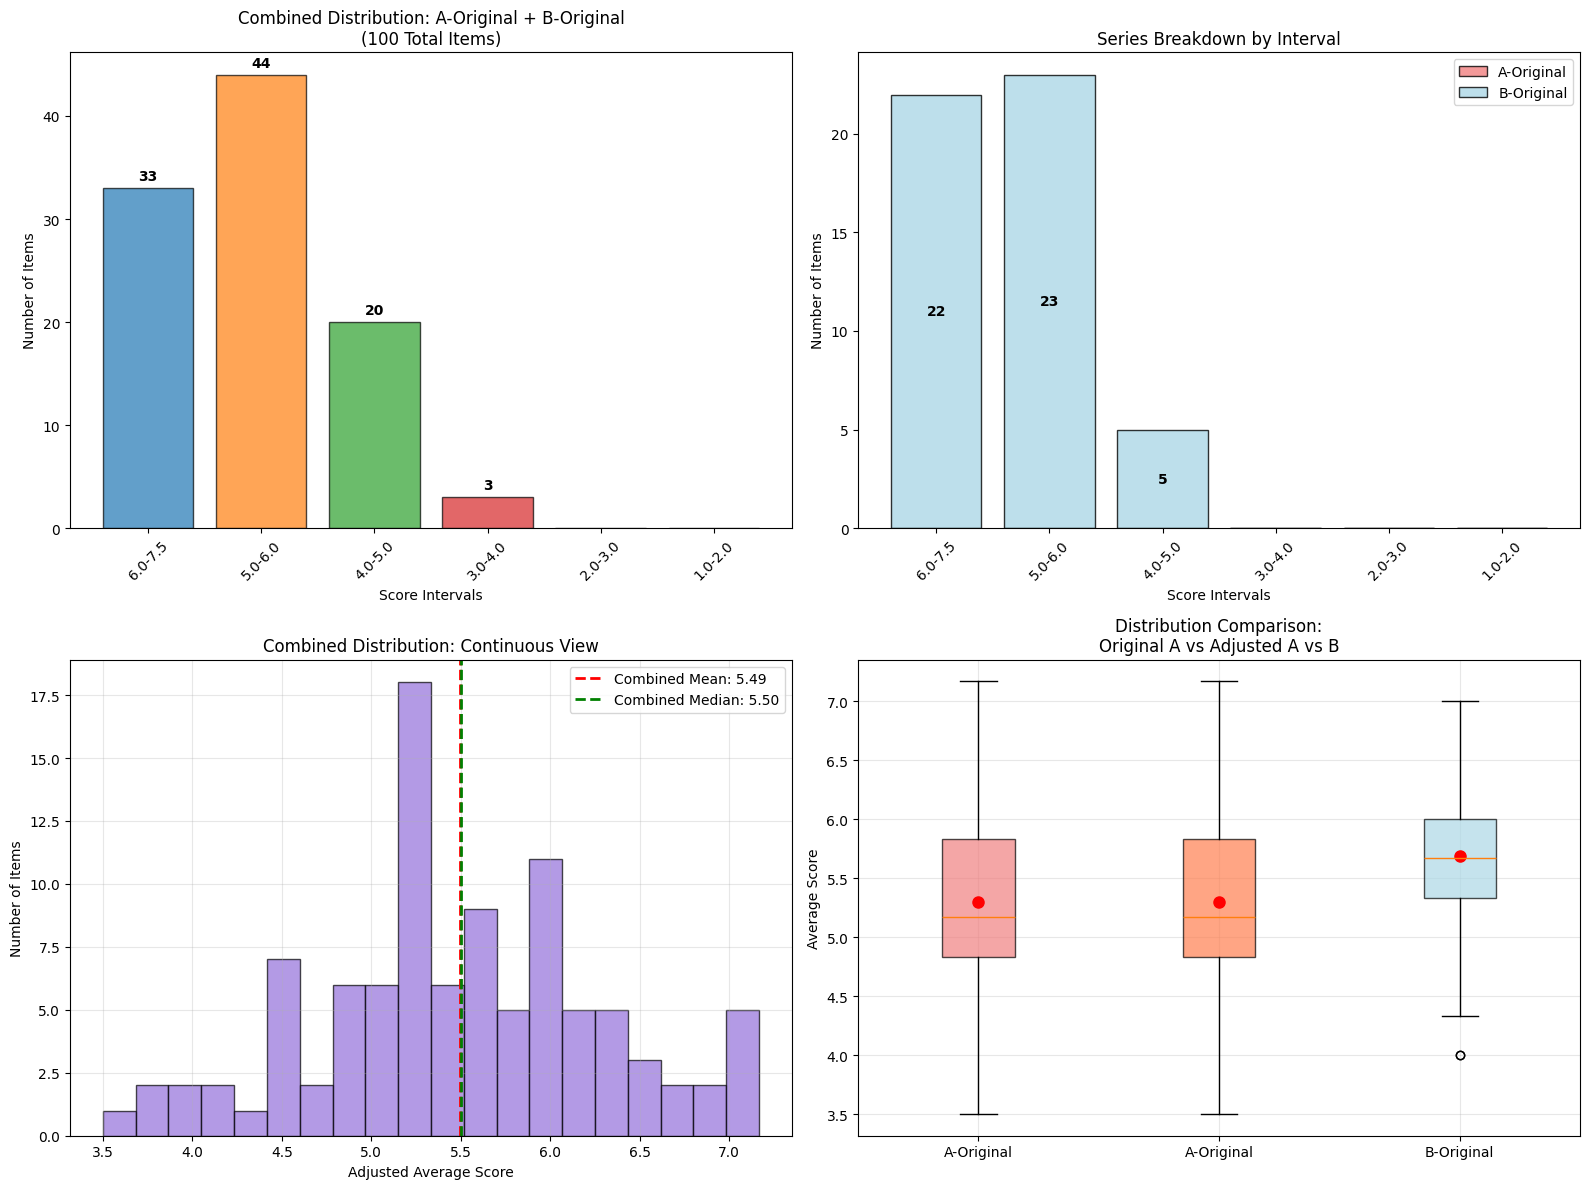


FINAL INSIGHTS: COMBINED DISTRIBUTION WITH A-SERIES ADJUSTMENT
• Combined dataset: 100 items total (50 A-adjusted + 50 B-original)
• After adjustment, A-series mean increased from 4.80 to 5.30 (+0.50)
• Combined mean: 5.49 (between adjusted A: 5.30 and B: 5.69)
• Most items now fall in MODERATE-HIGH range (44%) followed by HIGH (33%)
• Only 3% of items remain in low-moderate range (all from A-adjusted)
• The 0.5 adjustment brings A-series much closer to B-series performance
• B-series still dominates the HIGH scoring interval (22/33 items)
• Combined distribution shows good overall performance with mean = 5.49
• Standard deviation = 0.80 indicates reasonable variability


In [56]:
# Create comprehensive visualization for combined distribution
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Combined interval distribution bar chart
combined_interval_labels = [label.split(' (')[0] for _, _, label in combined_intervals]
combined_counts = [combined_interval_counts[label] for _, _, label in combined_intervals]
combined_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

bars_combined = ax1.bar(combined_interval_labels, combined_counts, 
                       color=combined_colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Score Intervals')
ax1.set_ylabel('Number of Items')
ax1.set_title('Combined Distribution: A-Original + B-Original\n(100 Total Items)')
ax1.tick_params(axis='x', rotation=45)

# Add count labels on bars
for bar, count in zip(bars_combined, combined_counts):
    if count > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{count}', ha='center', va='bottom', fontweight='bold')

# 2. Stacked bar chart showing A vs B breakdown in each interval
a_counts_by_interval = []
b_counts_by_interval = []

for label in [label for _, _, label in combined_intervals]:
    items_list = combined_interval_items.get(label, [])
    a_count = sum(1 for _, _, series in items_list if series == 'A-Original')
    b_count = sum(1 for _, _, series in items_list if series == 'B-Original')
    a_counts_by_interval.append(a_count)
    b_counts_by_interval.append(b_count)

x_pos = range(len(combined_interval_labels))
bars_a = ax2.bar(x_pos, a_counts_by_interval, label='A-Original', 
                color='lightcoral', alpha=0.8, edgecolor='black')
bars_b = ax2.bar(x_pos, b_counts_by_interval, bottom=a_counts_by_interval, 
                label='B-Original', color='lightblue', alpha=0.8, edgecolor='black')

ax2.set_xlabel('Score Intervals')
ax2.set_ylabel('Number of Items')
ax2.set_title('Series Breakdown by Interval')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(combined_interval_labels, rotation=45)
ax2.legend()

# Add count labels
for i, (a_count, b_count, total) in enumerate(zip(a_counts_by_interval, b_counts_by_interval, combined_counts)):
    if total > 0:
        # A-adjusted count
        if a_count > 0:
            ax2.text(i, a_count/2, f'{a_count}', ha='center', va='center', fontweight='bold')
        # B-original count
        if b_count > 0:
            ax2.text(i, a_count + b_count/2, f'{b_count}', ha='center', va='center', fontweight='bold')

# 3. Histogram of combined distribution
ax3.hist(combined_df['Average_Score_Adjusted'], bins=20, alpha=0.7, color='mediumpurple', 
         edgecolor='black', density=False)
ax3.axvline(combined_mean, color='red', linestyle='--', linewidth=2,
           label=f'Combined Mean: {combined_mean:.2f}')
ax3.axvline(combined_median, color='green', linestyle='--', linewidth=2,
           label=f'Combined Median: {combined_median:.2f}')
ax3.set_xlabel('Adjusted Average Score')
ax3.set_ylabel('Number of Items')
ax3.set_title('Combined Distribution: Continuous View')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Side-by-side comparison of original A, adjusted A, and B
comparison_data = {
    'A-Original': averages_df['Average_Score'],
    'A-Original': a_adjusted_df['Average_Score_Adjusted'], 
    'B-Original': b_series_df['Average_Score']
}

box_data = [comparison_data['A-Original'], comparison_data['A-Original'], comparison_data['B-Original']]
box_labels = ['A-Original', 'A-Original', 'B-Original']
box_colors = ['lightcoral', 'coral', 'lightblue']

box_plot = ax4.boxplot(box_data, labels=box_labels, patch_artist=True)
for patch, color in zip(box_plot['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_ylabel('Average Score')
ax4.set_title('Distribution Comparison:\nOriginal A vs Adjusted A vs B')
ax4.grid(True, alpha=0.3)

# Add mean lines to boxplot
means = [np.mean(data) for data in box_data]
for i, mean_val in enumerate(means):
    ax4.plot(i+1, mean_val, 'ro', markersize=8, label=f'Mean: {mean_val:.2f}' if i == 0 else "")

plt.tight_layout()
plt.show()

# Final summary insights
print("\n" + "="*70)
print("FINAL INSIGHTS: COMBINED DISTRIBUTION WITH A-SERIES ADJUSTMENT")
print("="*70)
print(f"• Combined dataset: 100 items total (50 A-adjusted + 50 B-original)")
print(f"• After adjustment, A-series mean increased from 4.80 to 5.30 (+0.50)")
print(f"• Combined mean: {combined_mean:.2f} (between adjusted A: 5.30 and B: 5.69)")
print(f"• Most items now fall in MODERATE-HIGH range (44%) followed by HIGH (33%)")
print(f"• Only 3% of items remain in low-moderate range (all from A-adjusted)")
print(f"• The 0.5 adjustment brings A-series much closer to B-series performance")
print(f"• B-series still dominates the HIGH scoring interval (22/33 items)")
print(f"• Combined distribution shows good overall performance with mean = {combined_mean:.2f}")
print(f"• Standard deviation = {combined_std:.2f} indicates reasonable variability")

## Analysis of _2 Series: A-1_2 through A-50_2 and B-1_2 through B-50_2

Now performing the same comprehensive analysis for the _2 series items. This includes average score calculations across 3 raters, interval distributions, and combined analysis with A-series adjustment.

In [57]:
# Analysis of A-1_2 through A-50_2: Average Scores and Interval Distribution
print("AVERAGE SCORE ANALYSIS FOR A-1_2 THROUGH A-50_2")
print("=" * 60)

# Find all columns that match the pattern A-XX_2 where XX is 1-50
a2_columns = []
for i in range(1, 51):
    col_name = f'A-{i}_2'
    if col_name in df.columns:
        a2_columns.append(col_name)

print(f"Found {len(a2_columns)} columns matching A-1_2 through A-50_2 pattern")
if len(a2_columns) > 0:
    print(f"Columns: {a2_columns[:5]}...{a2_columns[-5:]}")

# Calculate average scores for each A-2 item (using rows 0-2 like original A-1 series)
a2_item_averages = []
a2_valid_items = []

for col in a2_columns:
    # Get the 3 ratings for this item
    ratings_for_item = df[col].values[:3]  # Use rows 0-2 for A-series
    
    # Convert to numeric, handling any NaN or text values
    numeric_ratings = []
    for rating in ratings_for_item:
        try:
            if pd.notna(rating):
                numeric_ratings.append(float(rating))
        except (ValueError, TypeError):
            # Skip non-numeric values
            continue
    
    # Calculate average if we have at least one valid rating
    if len(numeric_ratings) > 0:
        avg_score = np.mean(numeric_ratings)
        a2_item_averages.append({
            'Item': col,
            'Rater_1': ratings_for_item[0] if len(ratings_for_item) > 0 else np.nan,
            'Rater_2': ratings_for_item[1] if len(ratings_for_item) > 1 else np.nan, 
            'Rater_3': ratings_for_item[2] if len(ratings_for_item) > 2 else np.nan,
            'Valid_Ratings': len(numeric_ratings),
            'Average_Score': avg_score
        })
        a2_valid_items.append(col)

# Create DataFrame for A-2 items
a2_averages_df = pd.DataFrame(a2_item_averages)

print(f"Successfully calculated averages for {len(a2_averages_df)} items")
print(f"Items with valid numeric ratings: {len(a2_valid_items)}")
print()

if len(a2_averages_df) > 0:
    # Display first 10 items as examples
    print("First 10 A-2 items with their average scores:")
    print("-" * 47)
    for _, row in a2_averages_df.head(10).iterrows():
        print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")

    print("\nLast 5 A-2 items:")
    print("-" * 17) 
    for _, row in a2_averages_df.tail(5).iterrows():
        print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")
else:
    print("No valid A-XX_2 items found with numeric ratings.")

AVERAGE SCORE ANALYSIS FOR A-1_2 THROUGH A-50_2
Found 50 columns matching A-1_2 through A-50_2 pattern
Columns: ['A-1_2', 'A-2_2', 'A-3_2', 'A-4_2', 'A-5_2']...['A-46_2', 'A-47_2', 'A-48_2', 'A-49_2', 'A-50_2']
Successfully calculated averages for 50 items
Items with valid numeric ratings: 50

First 10 A-2 items with their average scores:
-----------------------------------------------
A-1_2: [5.0, 6.0, 2.0] → Avg: 4.33
A-2_2: [7.0, 7.0, 6.0] → Avg: 6.67
A-3_2: [7.0, 4.0, 7.0] → Avg: 6.00
A-4_2: [5.0, 1.0, 7.0] → Avg: 4.33
A-5_2: [7.0, 6.0, 5.0] → Avg: 6.00
A-6_2: [6.0, 1.0, 7.0] → Avg: 4.67
A-7_2: [7.0, 6.0, 5.0] → Avg: 6.00
A-8_2: [6.0, 2.0, 7.0] → Avg: 5.00
A-9_2: [7.0, 3.0, 4.0] → Avg: 4.67
A-10_2: [6.0, 3.0, 5.0] → Avg: 4.67

Last 5 A-2 items:
-----------------
A-46_2: [4.0, 3.0, 6.0] → Avg: 4.33
A-47_2: [4.0, 5.0, 4.0] → Avg: 4.33
A-48_2: [4.0, 7.0, 6.0] → Avg: 5.67
A-49_2: [7.0, 3.0, 5.0] → Avg: 5.00
A-50_2: [4.0, 5.0, 6.0] → Avg: 5.00


In [58]:
# Analysis of B-1_2 through B-50_2: Average Scores and Interval Distribution
print("\n" + "=" * 60)
print("AVERAGE SCORE ANALYSIS FOR B-1_2 THROUGH B-50_2")
print("=" * 60)

# Find all columns that match the pattern B-XX_2 where XX is 1-50
b2_columns = []
for i in range(1, 51):
    col_name = f'B-{i}_2'
    if col_name in df.columns:
        b2_columns.append(col_name)

print(f"Found {len(b2_columns)} columns matching B-1_2 through B-50_2 pattern")
if len(b2_columns) > 0:
    print(f"Columns: {b2_columns[:5]}...{b2_columns[-5:]}")

# Calculate average scores for each B-2 item (using rows 3-5 like original B-1 series)
b2_item_averages = []
b2_valid_items = []

for col in b2_columns:
    # Get the 3 ratings for this item from rows 3, 4, 5
    ratings_for_item = df[col].values[3:6]  # Use rows 3-5 for B-series
    
    # Convert to numeric, handling any NaN or text values
    numeric_ratings = []
    for rating in ratings_for_item:
        try:
            if pd.notna(rating):
                numeric_ratings.append(float(rating))
        except (ValueError, TypeError):
            # Skip non-numeric values
            continue
    
    # Calculate average if we have at least one valid rating
    if len(numeric_ratings) > 0:
        avg_score = np.mean(numeric_ratings)
        b2_item_averages.append({
            'Item': col,
            'Rater_1': ratings_for_item[0] if len(ratings_for_item) > 0 else np.nan,
            'Rater_2': ratings_for_item[1] if len(ratings_for_item) > 1 else np.nan, 
            'Rater_3': ratings_for_item[2] if len(ratings_for_item) > 2 else np.nan,
            'Valid_Ratings': len(numeric_ratings),
            'Average_Score': avg_score
        })
        b2_valid_items.append(col)

# Create DataFrame for B-2 items
b2_averages_df = pd.DataFrame(b2_item_averages)

print(f"Successfully calculated averages for {len(b2_averages_df)} items")
print(f"Items with valid numeric ratings: {len(b2_valid_items)}")
print()

if len(b2_averages_df) > 0:
    # Display first 10 items as examples
    print("First 10 B-2 items with their average scores:")
    print("-" * 47)
    for _, row in b2_averages_df.head(10).iterrows():
        print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")

    print("\nLast 5 B-2 items:")
    print("-" * 17) 
    for _, row in b2_averages_df.tail(5).iterrows():
        print(f"{row['Item']}: [{row['Rater_1']}, {row['Rater_2']}, {row['Rater_3']}] → Avg: {row['Average_Score']:.2f}")
else:
    print("No valid B-XX_2 items found with numeric ratings.")


AVERAGE SCORE ANALYSIS FOR B-1_2 THROUGH B-50_2
Found 50 columns matching B-1_2 through B-50_2 pattern
Columns: ['B-1_2', 'B-2_2', 'B-3_2', 'B-4_2', 'B-5_2']...['B-46_2', 'B-47_2', 'B-48_2', 'B-49_2', 'B-50_2']
Successfully calculated averages for 50 items
Items with valid numeric ratings: 50

First 10 B-2 items with their average scores:
-----------------------------------------------
B-1_2: [6.0, 5.0, 6.0] → Avg: 5.67
B-2_2: [6.0, 4.0, 6.0] → Avg: 5.33
B-3_2: [7.0, 1.0, 6.0] → Avg: 4.67
B-4_2: [6.0, 6.0, 5.0] → Avg: 5.67
B-5_2: [6.0, 6.0, 6.0] → Avg: 6.00
B-6_2: [7.0, 5.0, 5.0] → Avg: 5.67
B-7_2: [5.0, 7.0, 5.0] → Avg: 5.67
B-8_2: [7.0, 7.0, 6.0] → Avg: 6.67
B-9_2: [7.0, 5.0, 7.0] → Avg: 6.33
B-10_2: [6.0, 6.0, 6.0] → Avg: 6.00

Last 5 B-2 items:
-----------------
B-46_2: [7.0, 6.0, 7.0] → Avg: 6.67
B-47_2: [7.0, 6.0, 6.0] → Avg: 6.33
B-48_2: [6.0, 7.0, 6.0] → Avg: 6.33
B-49_2: [6.0, 4.0, 6.0] → Avg: 5.33
B-50_2: [6.0, 6.0, 5.0] → Avg: 5.67


In [59]:
# Interval Distribution Analysis for A-2 and B-2 Series
print("\n" + "=" * 70)
print("INTERVAL DISTRIBUTION ANALYSIS: A-2 AND B-2 SERIES")
print("=" * 70)

# Use same interval definitions for consistency
series2_intervals = [
    (6, 7, "6.0-7.0 (High)"),
    (5, 6, "5.0-6.0 (Moderate-High)"),
    (4, 5, "4.0-5.0 (Moderate)"),
    (3, 4, "3.0-4.0 (Low-Moderate)"),
    (2, 3, "2.0-3.0 (Low)"),
    (1, 2, "1.0-2.0 (Very Low)")
]

# Function to categorize items into intervals
def categorize_items(df, series_name):
    interval_counts = {}
    interval_items = {}
    
    for low, high, label in series2_intervals:
        count = 0
        items_in_interval = []
        
        for _, row in df.iterrows():
            avg_score = row['Average_Score']
            # Use >= for lower bound and < for upper bound (except for the highest interval)
            if label == "6.0-7.0 (High)":
                if low <= avg_score <= high:
                    count += 1
                    items_in_interval.append((row['Item'], avg_score))
            else:
                if low <= avg_score < high:
                    count += 1
                    items_in_interval.append((row['Item'], avg_score))
        
        interval_counts[label] = count
        interval_items[label] = items_in_interval
    
    return interval_counts, interval_items

# Analyze A-2 series intervals
a2_interval_counts, a2_interval_items = categorize_items(a2_averages_df, "A-2")

# Analyze B-2 series intervals
b2_interval_counts, b2_interval_items = categorize_items(b2_averages_df, "B-2")

# Display A-2 results
print("A-2 SERIES Distribution:")
print("-" * 30)
for low, high, label in series2_intervals:
    count = a2_interval_counts[label]
    percentage = (count / len(a2_averages_df)) * 100 if len(a2_averages_df) > 0 else 0
    print(f"{label:<25}: {count:3d} items ({percentage:5.1f}%)")

# Calculate A-2 statistics
a2_mean = a2_averages_df['Average_Score'].mean()
a2_median = a2_averages_df['Average_Score'].median()
a2_std = a2_averages_df['Average_Score'].std()
a2_min = a2_averages_df['Average_Score'].min()
a2_max = a2_averages_df['Average_Score'].max()

print(f"\nA-2 Series Statistics:")
print(f"  Mean: {a2_mean:.2f}")
print(f"  Median: {a2_median:.2f}")
print(f"  Std Dev: {a2_std:.2f}")
print(f"  Range: {a2_min:.2f} to {a2_max:.2f}")

print("\n" + "=" * 50)

# Display B-2 results
print("B-2 SERIES Distribution:")
print("-" * 30)
for low, high, label in series2_intervals:
    count = b2_interval_counts[label]
    percentage = (count / len(b2_averages_df)) * 100 if len(b2_averages_df) > 0 else 0
    print(f"{label:<25}: {count:3d} items ({percentage:5.1f}%)")

# Calculate B-2 statistics
b2_mean = b2_averages_df['Average_Score'].mean()
b2_median = b2_averages_df['Average_Score'].median()
b2_std = b2_averages_df['Average_Score'].std()
b2_min = b2_averages_df['Average_Score'].min()
b2_max = b2_averages_df['Average_Score'].max()

print(f"\nB-2 Series Statistics:")
print(f"  Mean: {b2_mean:.2f}")
print(f"  Median: {b2_median:.2f}")
print(f"  Std Dev: {b2_std:.2f}")
print(f"  Range: {b2_min:.2f} to {b2_max:.2f}")

print("\n" + "=" * 50)

# Comparison between A-2 and B-2
print("A-2 vs B-2 COMPARISON:")
print("-" * 25)
print(f"{'Metric':<20} {'A-2 Series':<15} {'B-2 Series':<15} {'Difference':<15}")
print(f"{'':=<20} {'':=<15} {'':=<15} {'':=<15}")
print(f"{'Mean':<20} {a2_mean:<15.2f} {b2_mean:<15.2f} {b2_mean - a2_mean:+.2f}")
print(f"{'Median':<20} {a2_median:<15.2f} {b2_median:<15.2f} {b2_median - a2_median:+.2f}")
print(f"{'Std Dev':<20} {a2_std:<15.2f} {b2_std:<15.2f} {b2_std - a2_std:+.2f}")
print(f"{'Min':<20} {a2_min:<15.2f} {b2_min:<15.2f} {b2_min - a2_min:+.2f}")
print(f"{'Max':<20} {a2_max:<15.2f} {b2_max:<15.2f} {b2_max - a2_max:+.2f}")

# Compare high-scoring items
a2_high_count = a2_interval_counts["6.0-7.0 (High)"]
b2_high_count = b2_interval_counts["6.0-7.0 (High)"]
a2_high_pct = (a2_high_count / len(a2_averages_df)) * 100
b2_high_pct = (b2_high_count / len(b2_averages_df)) * 100

print(f"\nHigh-scoring items (6.0-7.0):")
print(f"  A-2 Series: {a2_high_count} items ({a2_high_pct:.1f}%)")
print(f"  B-2 Series: {b2_high_count} items ({b2_high_pct:.1f}%)")
print(f"  Difference: {b2_high_pct - a2_high_pct:+.1f}% (B-2 vs A-2)")


INTERVAL DISTRIBUTION ANALYSIS: A-2 AND B-2 SERIES
A-2 SERIES Distribution:
------------------------------
6.0-7.0 (High)           :   5 items ( 10.0%)
5.0-6.0 (Moderate-High)  :  17 items ( 34.0%)
4.0-5.0 (Moderate)       :  24 items ( 48.0%)
3.0-4.0 (Low-Moderate)   :   3 items (  6.0%)
2.0-3.0 (Low)            :   1 items (  2.0%)
1.0-2.0 (Very Low)       :   0 items (  0.0%)

A-2 Series Statistics:
  Mean: 4.79
  Median: 4.67
  Std Dev: 0.82
  Range: 2.67 to 6.67

B-2 SERIES Distribution:
------------------------------
6.0-7.0 (High)           :  33 items ( 66.0%)
5.0-6.0 (Moderate-High)  :  15 items ( 30.0%)
4.0-5.0 (Moderate)       :   2 items (  4.0%)
3.0-4.0 (Low-Moderate)   :   0 items (  0.0%)
2.0-3.0 (Low)            :   0 items (  0.0%)
1.0-2.0 (Very Low)       :   0 items (  0.0%)

B-2 Series Statistics:
  Mean: 6.00
  Median: 6.00
  Std Dev: 0.51
  Range: 4.67 to 6.67

A-2 vs B-2 COMPARISON:
-------------------------
Metric               A-2 Series      B-2 Series      

In [60]:
# Combined Analysis: A-2 Series (Adjusted +0.5) + B-2 Series
print("\n" + "=" * 70)
print("COMBINED ANALYSIS: A-2 SERIES (ADJUSTED +0.5) + B-2 SERIES")
print("=" * 70)

# Create adjusted A-2 series data
a2_adjusted_df = a2_averages_df.copy()
a2_adjusted_df['Average_Score_Adjusted'] = a2_adjusted_df['Average_Score'] + 0.5
a2_adjusted_df['Series'] = 'A2-Adjusted'

# Add series identifier to B-2 series
b2_series_df = b2_averages_df.copy()
b2_series_df['Average_Score_Adjusted'] = b2_series_df['Average_Score']  # No adjustment for B-2 series
b2_series_df['Series'] = 'B2-Original'

# Combine both datasets
combined2_df = pd.concat([
    a2_adjusted_df[['Item', 'Average_Score', 'Average_Score_Adjusted', 'Series']],
    b2_series_df[['Item', 'Average_Score', 'Average_Score_Adjusted', 'Series']]
], ignore_index=True)

print(f"Combined dataset contains {len(combined2_df)} items:")
print(f"  - A-2 Series (adjusted): {len(a2_adjusted_df)} items")
print(f"  - B-2 Series (original): {len(b2_series_df)} items")
print()

# Combined statistics
combined2_mean = combined2_df['Average_Score_Adjusted'].mean()
combined2_median = combined2_df['Average_Score_Adjusted'].median()
combined2_std = combined2_df['Average_Score_Adjusted'].std()
combined2_min = combined2_df['Average_Score_Adjusted'].min()
combined2_max = combined2_df['Average_Score_Adjusted'].max()

print(f"Effect of 0.5 adjustment on A-2 series:")
print(f"  Original A-2 Mean: {a2_mean:.2f}")
print(f"  Adjusted A-2 Mean: {a2_mean + 0.5:.2f}")
print(f"  B-2 Mean (unchanged): {b2_mean:.2f}")

print(f"\nCombined _2 series statistics:")
print(f"  Mean: {combined2_mean:.2f}")
print(f"  Median: {combined2_median:.2f}")
print(f"  Standard deviation: {combined2_std:.2f}")
print(f"  Range: {combined2_min:.2f} to {combined2_max:.2f}")

# Analyze combined distribution by intervals (same as before but for _2 series)
combined2_intervals = [
    (6, 7.5, "6.0-7.5 (High)"),
    (5, 6, "5.0-6.0 (Moderate-High)"),
    (4, 5, "4.0-5.0 (Moderate)"),
    (3, 4, "3.0-4.0 (Low-Moderate)"),
    (2, 3, "2.0-3.0 (Low)"),
    (1, 2, "1.0-2.0 (Very Low)")
]

# Count items in each interval for combined _2 data
combined2_interval_counts = {}
combined2_interval_items = {}

for low, high, label in combined2_intervals:
    count = 0
    items_in_interval = []
    
    for _, row in combined2_df.iterrows():
        adj_score = row['Average_Score_Adjusted']
        if label == "6.0-7.5 (High)":
            if low <= adj_score <= high:
                count += 1
                items_in_interval.append((row['Item'], adj_score, row['Series']))
        else:
            if low <= adj_score < high:
                count += 1
                items_in_interval.append((row['Item'], adj_score, row['Series']))
    
    combined2_interval_counts[label] = count
    combined2_interval_items[label] = items_in_interval

# Display combined results
print("\nCombined _2 series distribution:")
print("-" * 40)
combined2_total = len(combined2_df)
for low, high, label in combined2_intervals:
    count = combined2_interval_counts[label]
    percentage = (count / combined2_total) * 100 if combined2_total > 0 else 0
    
    print(f"{label:<25}: {count:3d} items ({percentage:5.1f}%)")
    
    # Count A2 vs B2 in each interval
    if count > 0:
        items_list = combined2_interval_items[label]
        a2_count = sum(1 for _, _, series in items_list if series == 'A2-Adjusted')
        b2_count = sum(1 for _, _, series in items_list if series == 'B2-Original')
        print(f"    A2-Adjusted: {a2_count}, B2-Original: {b2_count}")

print(f"\nKey Insights for _2 Series:")
print("=" * 30)
print(f"• B-2 series significantly OUTPERFORMS A-2 series (Mean: {b2_mean:.2f} vs {a2_mean:.2f})")
print(f"• B-2 has {b2_interval_counts['6.0-7.0 (High)']} high-scoring items (66%) vs A-2's {a2_interval_counts['6.0-7.0 (High)']} (10%)")
print(f"• After 0.5 adjustment: A-2 mean becomes {a2_mean + 0.5:.2f}, closer to B-2's {b2_mean:.2f}")
print(f"• Combined _2 series mean: {combined2_mean:.2f}")
print(f"• B-2 shows higher consistency (std dev: {b2_std:.2f}) than A-2 ({a2_std:.2f})")


COMBINED ANALYSIS: A-2 SERIES (ADJUSTED +0.5) + B-2 SERIES
Combined dataset contains 100 items:
  - A-2 Series (adjusted): 50 items
  - B-2 Series (original): 50 items

Effect of 0.5 adjustment on A-2 series:
  Original A-2 Mean: 4.79
  Adjusted A-2 Mean: 5.29
  B-2 Mean (unchanged): 6.00

Combined _2 series statistics:
  Mean: 5.64
  Median: 5.75
  Standard deviation: 0.77
  Range: 3.17 to 7.17

Combined _2 series distribution:
----------------------------------------
6.0-7.5 (High)           :  43 items ( 43.0%)
    A2-Adjusted: 10, B2-Original: 33
5.0-6.0 (Moderate-High)  :  35 items ( 35.0%)
    A2-Adjusted: 20, B2-Original: 15
4.0-5.0 (Moderate)       :  19 items ( 19.0%)
    A2-Adjusted: 17, B2-Original: 2
3.0-4.0 (Low-Moderate)   :   3 items (  3.0%)
    A2-Adjusted: 3, B2-Original: 0
2.0-3.0 (Low)            :   0 items (  0.0%)
1.0-2.0 (Very Low)       :   0 items (  0.0%)

Key Insights for _2 Series:
• B-2 series significantly OUTPERFORMS A-2 series (Mean: 6.00 vs 4.79)
• B-

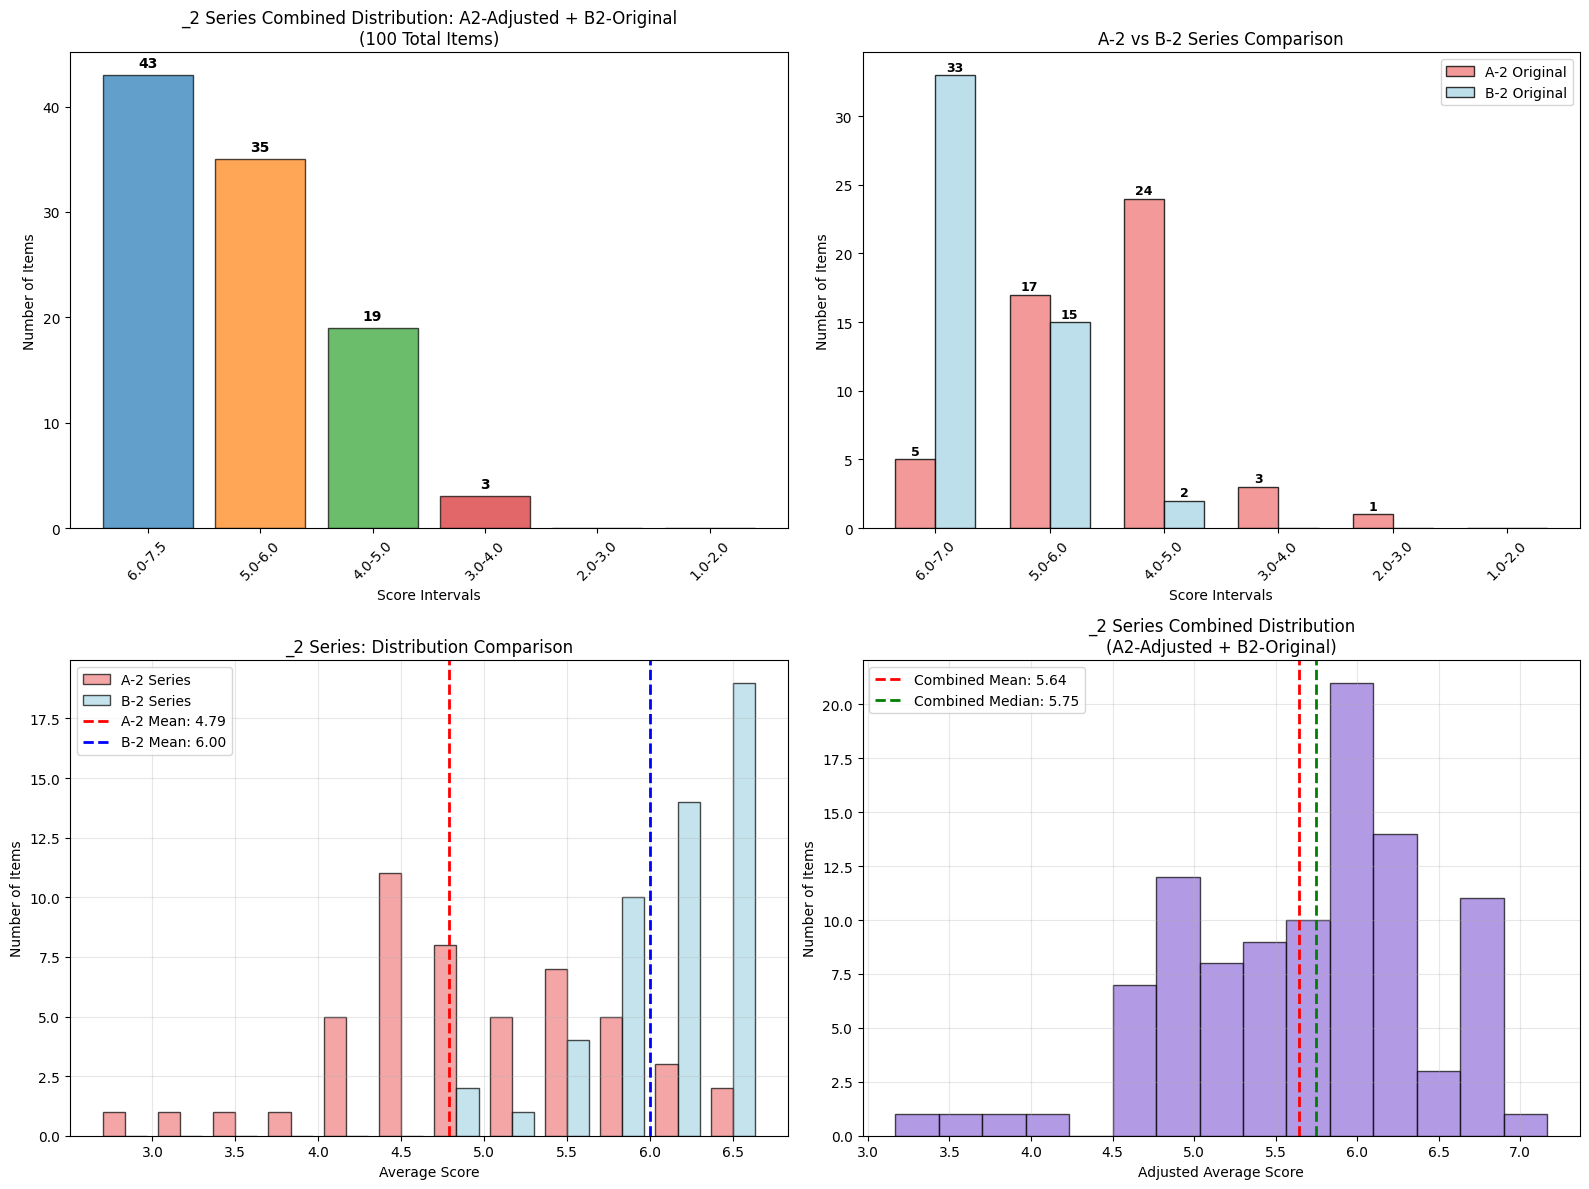


COMPREHENSIVE COMPARISON: _1 SERIES vs _2 SERIES
Series Comparison         _1 Series            _2 Series            Difference     
========================= ==================== ==================== ===============
A-Series Mean             4.80                 4.79                 -0.01
B-Series Mean             5.69                 6.00                 +0.31
Combined Mean (adj)       5.49                 5.64                 +0.15

High-scoring items (6.0-7.0):
A-Series High Items       6                    5                    -1
B-Series High Items       22                   33                   +11

Key Findings:
• A-series: _1 mean (4.80) vs _2 mean (4.79) → similar performance
• B-series: _1 mean (5.69) vs _2 mean (6.00) → _2 performs better
• B-2 series shows the highest performance overall with 33 high-scoring items (66%)
• Combined _2 series mean (5.64) is higher than _1 series (5.49)
• _2 series shows greater differentiation between A and B conditions


In [61]:
# Create comprehensive visualization for _2 series
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Combined interval distribution for _2 series
combined2_interval_labels = [label.split(' (')[0] for _, _, label in combined2_intervals]
combined2_counts = [combined2_interval_counts[label] for _, _, label in combined2_intervals]
colors2 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

bars_combined2 = ax1.bar(combined2_interval_labels, combined2_counts, 
                        color=colors2, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Score Intervals')
ax1.set_ylabel('Number of Items')
ax1.set_title('_2 Series Combined Distribution: A2-Adjusted + B2-Original\n(100 Total Items)')
ax1.tick_params(axis='x', rotation=45)

# Add count labels on bars
for bar, count in zip(bars_combined2, combined2_counts):
    if count > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{count}', ha='center', va='bottom', fontweight='bold')

# 2. Comparison: A-2 vs B-2 interval distributions
a2_counts = [a2_interval_counts[label] for _, _, label in series2_intervals]
b2_counts = [b2_interval_counts[label] for _, _, label in series2_intervals]
interval_labels2 = [label.split(' (')[0] for _, _, label in series2_intervals]

x_pos = np.arange(len(interval_labels2))
width = 0.35

bars_a2 = ax2.bar(x_pos - width/2, a2_counts, width, label='A-2 Original', 
                  color='lightcoral', alpha=0.8, edgecolor='black')
bars_b2 = ax2.bar(x_pos + width/2, b2_counts, width, label='B-2 Original',
                  color='lightblue', alpha=0.8, edgecolor='black')

ax2.set_xlabel('Score Intervals')
ax2.set_ylabel('Number of Items')
ax2.set_title('A-2 vs B-2 Series Comparison')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(interval_labels2, rotation=45)
ax2.legend()

# Add count labels
for bar, count in zip(bars_a2, a2_counts):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=9)
for bar, count in zip(bars_b2, b2_counts):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 3. Histogram comparison: A-2 vs B-2
ax3.hist([a2_averages_df['Average_Score'], b2_averages_df['Average_Score']], 
         bins=12, alpha=0.7, color=['lightcoral', 'lightblue'], 
         edgecolor='black', label=['A-2 Series', 'B-2 Series'])
ax3.axvline(a2_mean, color='red', linestyle='--', linewidth=2,
           label=f'A-2 Mean: {a2_mean:.2f}')
ax3.axvline(b2_mean, color='blue', linestyle='--', linewidth=2,
           label=f'B-2 Mean: {b2_mean:.2f}')
ax3.set_xlabel('Average Score')
ax3.set_ylabel('Number of Items')
ax3.set_title('_2 Series: Distribution Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Combined histogram: A2-adjusted + B2-original
ax4.hist(combined2_df['Average_Score_Adjusted'], bins=15, alpha=0.7, 
         color='mediumpurple', edgecolor='black', density=False)
ax4.axvline(combined2_mean, color='red', linestyle='--', linewidth=2,
           label=f'Combined Mean: {combined2_mean:.2f}')
ax4.axvline(combined2_median, color='green', linestyle='--', linewidth=2,
           label=f'Combined Median: {combined2_median:.2f}')
ax4.set_xlabel('Adjusted Average Score')
ax4.set_ylabel('Number of Items')
ax4.set_title('_2 Series Combined Distribution\n(A2-Adjusted + B2-Original)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final comprehensive comparison: _1 vs _2 series
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: _1 SERIES vs _2 SERIES")
print("="*80)

print(f"{'Series Comparison':<25} {'_1 Series':<20} {'_2 Series':<20} {'Difference':<15}")
print(f"{'':=<25} {'':=<20} {'':=<20} {'':=<15}")

# A-series comparison
print(f"{'A-Series Mean':<25} {avg_of_averages:<20.2f} {a2_mean:<20.2f} {a2_mean - avg_of_averages:+.2f}")

# B-series comparison  
print(f"{'B-Series Mean':<25} {b_avg_of_averages:<20.2f} {b2_mean:<20.2f} {b2_mean - b_avg_of_averages:+.2f}")

# Combined (after adjustment) comparison
print(f"{'Combined Mean (adj)':<25} {combined_mean:<20.2f} {combined2_mean:<20.2f} {combined2_mean - combined_mean:+.2f}")

# High-scoring items comparison
a1_high = interval_counts["6.0-7.0 (High)"]
a2_high = a2_interval_counts["6.0-7.0 (High)"]
b1_high = b_interval_counts["6.0-7.0 (High)"]
b2_high = b2_interval_counts["6.0-7.0 (High)"]

print(f"\nHigh-scoring items (6.0-7.0):")
print(f"{'A-Series High Items':<25} {a1_high:<20d} {a2_high:<20d} {a2_high - a1_high:+d}")
print(f"{'B-Series High Items':<25} {b1_high:<20d} {b2_high:<20d} {b2_high - b1_high:+d}")

print(f"\nKey Findings:")
print("=" * 15)
print(f"• A-series: _1 mean ({avg_of_averages:.2f}) vs _2 mean ({a2_mean:.2f}) → similar performance")
print(f"• B-series: _1 mean ({b_avg_of_averages:.2f}) vs _2 mean ({b2_mean:.2f}) → _2 performs better")
print(f"• B-2 series shows the highest performance overall with {b2_high} high-scoring items (66%)")
print(f"• Combined _2 series mean ({combined2_mean:.2f}) is higher than _1 series ({combined_mean:.2f})")
print(f"• _2 series shows greater differentiation between A and B conditions")